In [2]:
!git pull

fatal: not a git repository (or any of the parent directories): .git


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import string


from sklearn.model_selection import train_test_split

In [10]:
%cd C:/Users/arpit/spring-2026-deep-learning-fragmented-id-resolution

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution


In [11]:
# Read the TSV files into the DataFrame
#Data Source Hasso Plattner Institut 
# NDPL - Non-duplicates
# DPL - Duplicates
# ncvoters - a snap shot of the snapshot: VR_Snapshot_20181106 
df_ncvoters = pd.read_csv(r'data/raw/ncvoters.tsv', sep='\t')
DPL = pd.read_csv(r'data/raw/ncvoters_DPL.tsv', sep='\t')
NDPL = pd.read_csv(r'data/raw/ncvoters_NDPL.tsv', sep='\t')

C:\Users\arpit\AppData\Local\Temp\ipykernel_35500\1529047839.py:6: DtypeWarning: Columns (59,65,89) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ncvoters = pd.read_csv(r'data/raw/ncvoters.tsv', sep='\t')


In [12]:
# Preprocessing for our fragemented ID analysis 
# Selecting identifyer variables not related to voting
df_ncvoters_frag_ID = df_ncvoters[[
#Stable Identifiers
#Only to be used for labeling /evaluation only 
# / not as a model feature
    'id', 'ncid', 'voter_reg_num', 
# Primary Model features - Strongest features, Strong entropy, Essential for matching
    #many variable such as name prefx and sufx are sparse we can either use none for missing or 0/1
    'first_name', 'midl_name', 'last_name', 'name_sufx_cd',
    #other varaiabes
# Adress Similarity features - Address is the second strongest identity anchor, 
    # Street name especially high discriminative signal # Unit numbers distinguish household
    #many variable such as unit designator are sparse we can either use none for missing or 0/1
    'house_num', 'street_name', 'street_dir', 'street_type_cd', 'unit_designator', 'unit_num', 'zip_code', 'res_city_desc',
#other varaiabes
# Demographic agreement indicators - Moderate/Supporting Features 
    # these will help us reduce false matches # they are agreement indicators, low-weight similarity features
    #age group rather than age because grouped/bin age is more stable
    'age', 'age_group', 'sex', 'race_code', 'race_desc', 'ethnic_code', 'ethnic_desc', 'birth_place',
# #other varaiabes 
 'phone_num','area_cd'   
 ]]
# print("\nSelected variables 'A' and 'C':")
print(df_ncvoters_frag_ID)

             id      ncid  voter_reg_num first_name  midl_name   last_name  \
0           277  aa173006        9132930  domenique       anna   gramolini   
1           566  aa175613        9136375    deborah                  wells   
2          1369  aa188072        9155533       evan  nathaniel     workman   
3          1567  by580879        9157283     alyssa   danielle      marion   
4          1583   ax51253        9157299    lacosta       gail  williamson   
...         ...       ...            ...        ...        ...         ...   
14178  14181892   er19108          19163     jerome     wilson      crouse   
14179  14182849  bn333629          71381      james    richard      dayton   
14180  14183213   en51685          77917       noah    matthew      pardue   
14181  14183530   er32617          62638     krista    stanley  williamson   
14182  14183738   er30307          60328      chara       lane    o connor   

      name_sufx_cd  house_num           street_name street_dir 

In [13]:
# Adding labels to DPL and NDPL
DPL['label'] = 1 
NDPL['label'] = 0


print(DPL.head(10))
print(NDPL.head(10))

        id1      id2  label
0  11401396   511079      1
1   3569312  9442163      1
2   3569312  9522852      1
3   3569312  9549525      1
4   9442163  9522852      1
5   9442163  9549525      1
6   9522852  9549525      1
7  12658910  3213055      1
8  12658910  3174121      1
9   3213055  3174121      1
        id1       id2  participation  label
0  11826037   3981077       0.428571      0
1  11914983   2089120       0.428571      0
2  10063200  14074062       0.428571      0
3  13740661  13779277       0.428571      0
4  12909240  12927497       0.428571      0
5  12496955  12523473       0.428571      0
6  10378846  10400866       0.428571      0
7  13145288   9989193       0.285714      0
8   9760941   9976890       0.285714      0
9   1027663    997075       0.285714      0


In [14]:
#Merge Duplicate and Non Duplicate pairs
pairs = pd.concat([DPL, NDPL])

print(pairs.head(20))
print(pairs.tail(20))


         id1       id2  label  participation
0   11401396    511079      1            NaN
1    3569312   9442163      1            NaN
2    3569312   9522852      1            NaN
3    3569312   9549525      1            NaN
4    9442163   9522852      1            NaN
5    9442163   9549525      1            NaN
6    9522852   9549525      1            NaN
7   12658910   3213055      1            NaN
8   12658910   3174121      1            NaN
9    3213055   3174121      1            NaN
10   1033927   9114975      1            NaN
11   8655919    847046      1            NaN
12   3462484  10261176      1            NaN
13    383933   7826253      1            NaN
14   7092750   7022921      1            NaN
15   1658211   6300974      1            NaN
16   9167292    377059      1            NaN
17  13224692   3594362      1            NaN
18    222684   3714715      1            NaN
19    299592   9279844      1            NaN
            id1       id2  label  participation
98122  

In [15]:
# merging ncvoters on DPL and NDPL
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id1",
    right_on="id",
    how="left"
)
print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id1              107961 non-null  int64  
 1   id2              107961 non-null  int64  
 2   label            107961 non-null  int64  
 3   participation    98142 non-null   float64
 4   id               107961 non-null  int64  
 5   ncid             107961 non-null  object 
 6   voter_reg_num    107961 non-null  int64  
 7   first_name       107961 non-null  object 
 8   midl_name        107961 non-null  object 
 9   last_name        107961 non-null  object 
 10  name_sufx_cd     107961 non-null  object 
 11  house_num        107961 non-null  int64  
 12  street_name      107961 non-null  object 
 13  street_dir       107961 non-null  object 
 14  street_type_cd   107961 non-null  object 
 15  unit_designator  107961 non-null  object 
 16  unit_num         107961 non-null  obje

In [16]:
#merging id2 
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id2",
    right_on="id",
    how="left",
    suffixes=("_1", "_2")
)

print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 54 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id1                107961 non-null  int64  
 1   id2                107961 non-null  int64  
 2   label              107961 non-null  int64  
 3   participation      98142 non-null   float64
 4   id_1               107961 non-null  int64  
 5   ncid_1             107961 non-null  object 
 6   voter_reg_num_1    107961 non-null  int64  
 7   first_name_1       107961 non-null  object 
 8   midl_name_1        107961 non-null  object 
 9   last_name_1        107961 non-null  object 
 10  name_sufx_cd_1     107961 non-null  object 
 11  house_num_1        107961 non-null  int64  
 12  street_name_1      107961 non-null  object 
 13  street_dir_1       107961 non-null  object 
 14  street_type_cd_1   107961 non-null  object 
 15  unit_designator_1  107961 non-null  object 
 16  un

Train Test Val Split

In [17]:
import networkx as nx
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split 

# only duplicates
dup_pairs = pairs[pairs["label"] == 1]

G = nx.Graph()

# add edges
G.add_edges_from(zip(dup_pairs["id1"], dup_pairs["id2"]))

# connected components = entity clusters
components = list(nx.connected_components(G))

In [18]:
# Adding ids back in data 

all_ids = set(df_ncvoters_frag_ID["id"])
ids_in_graph = set(G.nodes())

singletons = all_ids - ids_in_graph

for s in singletons:
    components.append({s})

In [19]:
# Split

train_groups, temp_groups = train_test_split(
    components,
    test_size=0.3,
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.5,
    random_state=42
)

In [20]:
#Converting groups to ids 
train_ids = set().union(*train_groups)
val_ids   = set().union(*val_groups)
test_ids  = set().union(*test_groups)

In [21]:
#bringing dups and non dups together

train_pairs = pairs[pairs["id1"].isin(train_ids) & pairs["id2"].isin(train_ids)]

val_pairs = pairs[pairs["id1"].isin(val_ids) & pairs["id2"].isin(val_ids)]

test_pairs = pairs[pairs["id1"].isin(test_ids) & pairs["id2"].isin(test_ids)]

In [22]:
print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 54677
Val: 3573
Test: 3870


In [23]:
print(df_ncvoters_frag_ID.columns)
print(pairs.columns)

print(train_pairs.columns)
print(val_pairs.columns)
print(test_pairs.columns)

Index(['id', 'ncid', 'voter_reg_num', 'first_name', 'midl_name', 'last_name',
       'name_sufx_cd', 'house_num', 'street_name', 'street_dir',
       'street_type_cd', 'unit_designator', 'unit_num', 'zip_code',
       'res_city_desc', 'age', 'age_group', 'sex', 'race_code', 'race_desc',
       'ethnic_code', 'ethnic_desc', 'birth_place', 'phone_num', 'area_cd'],
      dtype='object')
Index(['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1',
       'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1',
       'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1',
       'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1',
       'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1',
       'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1',
       'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2',
       'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2',
       'house_num_2', 'street_name_2'



 Augmented positives
 +  typos
  + nicknames
  + address abbreviation

 Hard negatives
  + same household
  + same same lastname
  + same firstname
  + suffix

Medium negative 
  + same first name negative  

Positives
  + same household
  + original duplicates
  +	typo duplicates
  + nickname duplicates
  + street abbreviation duplicates
  + multi-field duplicates

Negatives
 + household pairs
 + nickname negatives
 + suffix negatives
 + address formatting negatives


In [24]:
#Creating a new variable id_to_clusters to be used in augmented training cell - #4 household negatives 
id_to_cluster = {}
for cluster_id, component in enumerate(components):
    for voter_id in component:
        id_to_cluster[voter_id] = cluster_id

# singletons
next_id = len(components)
for v_id in df_ncvoters_frag_ID["id"]:
    if v_id not in id_to_cluster:
        id_to_cluster[v_id] = next_id
        next_id += 1

print(f"Total IDs mapped: {len(id_to_cluster)}")

Total IDs mapped: 14183


In [25]:
# 1. Utilities (names + street logic)

import random

nickname_dict = {
    "william": ["bill","billy","will"],
    "robert": ["bob","bobby","rob"],
    "james": ["jim","jimmy"],
    "john": ["jack","johnny"],
    "elizabeth": ["liz","beth","lizzy"],
    "margaret": ["maggie","meg","peggy"],
    "katherine": ["kate","kathy"],
    "sarah": ["sara"]
}

street_expand = {
    "st":"street",
    "rd":"road",
    "ave":"avenue",
    "dr":"drive",
    "ln":"lane",
    "blvd":"boulevard"
}

def nickname(name):
    n = str(name).lower()
    if n in nickname_dict:
        return random.choice(nickname_dict[n])
    for k,v in nickname_dict.items():
        if n in v:
            return k
    return name


def typo(name):
    name=list(str(name))
    if len(name)<3:
        return "".join(name)
    i=random.randint(0,len(name)-2)
    name[i],name[i+1]=name[i+1],name[i]
    return "".join(name)


def expand_street(st):
    s=str(st).lower()
    return street_expand.get(s,s)

    

In [26]:

# 2. Duplicate augmentation (label = 1) - This creates multi-field realistic duplicates.

def augment_duplicates(train_pairs):
    augmented = []
    for _, row in train_pairs.iterrows():
        if row["label"] != 1:
            continue
        r = row.copy()
        side1_changed = False
        side2_changed = False

        if random.random() < 0.4:
            if random.random() < 0.5:
                r["first_name_1"] = typo(r["first_name_1"])
                side1_changed = True
            else:
                r["first_name_2"] = typo(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed and random.random() < 0.5:
                r["first_name_1"] = nickname(r["first_name_1"])
                side1_changed = True
            elif not side2_changed:
                r["first_name_2"] = nickname(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed:
                r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
            elif not side2_changed:
                r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])

        augmented.append(r)
    return pd.DataFrame(augmented)

#aug_dups2 = augment_duplicates(train_pairs)
aug_dups2 = augment_duplicates(train_pairs)
print(aug_dups2.shape)
print(aug_dups2["first_name_1"].head())
print(train_pairs[train_pairs["label"]==1]["first_name_1"].head())

(6826, 54)
0       eric
1    semaje 
2    semaje 
3    semaje 
4     samaje
Name: first_name_1, dtype: object
0       eric
1    semaje 
2    semaje 
3    semaje 
4     samaje
Name: first_name_1, dtype: object


In [27]:
#3 adding steert_ type expansion in both direction 

def street_type_negatives(train_pairs, n=2000):
    pairs = []
    for _, row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"] == 1:
            continue
        # skip if both street types are empty
        if row["street_type_cd_1"] == "" and row["street_type_cd_2"] == "":
            continue
        r = row.copy()
        if random.random() < 0.5:
            r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
        else:
            r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])
        if r["street_type_cd_1"] != row["street_type_cd_1"] or \
           r["street_type_cd_2"] != row["street_type_cd_2"]:
            r["label"] = 0
            pairs.append(r)
        if len(pairs) >= n:
            break
    return pd.DataFrame(pairs)

In [ ]:
# ####We wanted: different people, same address --> confusing negative
#Reality:   same address → almost always same person in this dataset


# household_negatives isn't a useful hard negative generator for this specific dataset.
#  # 4. Hard negatives - We generate confusing but non-duplicate pairs. 
# # Household negatives (same address)
# # since this is being generated, I want to make sure to not accidentally append a known duplicate - cluster saftey
# def household_negatives(train_pairs,cluster_map, n=3000):

#     pairs=[]

#     groups=train_pairs.groupby(
#         ["house_num_1","street_name_1"]
#     )

#     for _,g in groups:

#         if len(g)<2:
#             continue

#         sample=g.sample(min(len(g),2))

#         r=sample.iloc[0].copy()

#         #cluster saftey check 
#         if cluster_map.get(sample.iloc[0]["id1"]) == cluster_map.get(sample.iloc[1]["id1"]):
#             continue

#         r["first_name_2"]=sample.iloc[1]["first_name_1"]
#         r["last_name_2"]=sample.iloc[1]["last_name_1"]

#         r["label"]=0
        

#         pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)

In [28]:
#5 Nickname negatives 
#this simply adds nickname negatives by swapping some first names to nick names in the NDPL

def nickname_negatives(train_pairs,n=2000):

    pairs=[]

    for _,row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"]==1: 
            continue

        r=row.copy()

        r["first_name_2"]=nickname(r["first_name_2"])

        if r["first_name_2"]!=row["first_name_2"]:

            r["label"]=0
            pairs.append(r)

        if len(pairs)>=n:
            break

    return pd.DataFrame(pairs)

In [ ]:
# # Suffix negatives Jr/Sr) - 0 in the negative data so this is meaningless it just would add noise and not signal 
# There 124 dups with suffixes — they're valid duplicates where one record has a missing suffix 
# #generating nonsensical suffix 
# def suffix_negatives(train_pairs,n=1000):

#     pairs=[]

#     for _,row in train_pairs.iterrows():
#          if row["label"] == 1:  # skip duplicates, work from negatives
#             continue
#         r=row.copy()

#         if pd.notna(row["name_sufx_cd_1"]):

#             r["name_sufx_cd_2"]="jr" if row["name_sufx_cd_1"]!="jr" else "sr"
#             r["label"]=0

#             pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)



Tested Suffix and it looks like it doesn't make sense to generate negative suffixes. 
* Because only dups would have junior-senior pairs. 
* could have non dups that are junior singleton and senior singleton. 
* the occurences of suffixes are sparse in our data
* we have 124 duplicate pairs with suffix mismatch -> valid raw data 

In [ ]:
# # Checking for confusable suffix cases in negatives
# confusable_negs = train_pairs[
#     (train_pairs["label"] == 0) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# # Check confusable suffix cases in duplicates
# confusable_dups = train_pairs[
#     (train_pairs["label"] == 1) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# print(f"Confusable suffix negatives: {confusable_negs}")
# print(f"Confusable suffix duplicates: {confusable_dups}")

# # Check how common suffixes are overall
# print(f"\nSuffix value counts id1:\n{train_pairs['name_sufx_cd_1'].value_counts()}")
# print(f"\nSuffix value counts id2:\n{train_pairs['name_sufx_cd_2'].value_counts()}")

In [ ]:
# #how many are missing suffixes on one side?
# # Verify - how many are just missing suffix on one side
# missing_one_side = suspicious[
#     (suspicious["name_sufx_cd_1"] == "") | 
#     (suspicious["name_sufx_cd_2"] == "")
# ].shape[0]

# actual_conflict = suspicious[
#     (suspicious["name_sufx_cd_1"] != "") & 
#     (suspicious["name_sufx_cd_2"] != "") &
#     (suspicious["name_sufx_cd_1"] != suspicious["name_sufx_cd_2"])
# ].shape[0]

# print(f"Missing suffix on one side: {missing_one_side}")
# print(f"Actual SR/JR conflicts: {actual_conflict}")

In [29]:
# augmented training set 
aug_dups = augment_duplicates(train_pairs)

# hard 
street_neg = street_type_negatives(train_pairs)
#household_neg = household_negatives(train_pairs, id_to_cluster)
nickname_neg = nickname_negatives(train_pairs)

train_pairs_aug = pd.concat(
    [train_pairs,
     aug_dups, 
     street_neg,
    #household_neg, 
     nickname_neg],
    ignore_index=True
)

In [30]:
#adding augmentation to val and test splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
# train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Checking that all augmentations and hard negatives changes worked on TRAINING SET 

In [31]:
# 1. Typo check - first_name should differ from original
typo_changes = aug_dups2[aug_dups2["first_name_1"] != train_pairs.loc[aug_dups2.index, "first_name_1"].values]
print(f"Typo applied to first_name_1: {len(typo_changes)}")

typo_changes2 = aug_dups2[aug_dups2["first_name_2"] != train_pairs.loc[aug_dups2.index, "first_name_2"].values]
print(f"Typo applied to first_name_2: {len(typo_changes2)}")

# 2. Nickname check - first_name should be in nickname dict values
nickname_changes1 = aug_dups2[aug_dups2["first_name_1"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_1: {len(nickname_changes1)}")

nickname_changes2 = aug_dups2[aug_dups2["first_name_2"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_2: {len(nickname_changes2)}")

# 3. Street expansion check - should see full words not abbreviations
expanded1 = aug_dups2[aug_dups2["street_type_cd_1"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_1: {len(expanded1)}")

expanded2 = aug_dups2[aug_dups2["street_type_cd_2"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_2: {len(expanded2)}")

# 4. Nickname negatives check
nick_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Nickname negatives: {len(nick_negs)}")

# 5. Street type negatives check
street_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]
print(f"Street type negatives: {len(street_negs)}")

# # 6. Household negatives check
# household_negs = train_pairs_aug[
#     (train_pairs_aug["label"] == 0) &
#     (train_pairs_aug["house_num_1"] == train_pairs_aug["house_num_2"]) &
#     (train_pairs_aug["street_name_1"] == train_pairs_aug["street_name_2"])
# ]
# print(f"Household negatives: {len(household_negs)}")

# 7. Overall label distribution
counts = train_pairs_aug["label"].value_counts()
pcts = train_pairs_aug["label"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "percentage": pcts.round(2)}))

Typo applied to first_name_1: 1400
Typo applied to first_name_2: 1387
Nickname in first_name_1: 436
Nickname in first_name_2: 441
Street expanded in street_type_cd_1: 933
Street expanded in street_type_cd_2: 304
Nickname negatives: 2303
Street type negatives: 2000
       count  percentage
label                   
0      51851       79.16
1      13652       20.84


In [32]:
#How hard are our negatives?

# Check nickname negatives - how often do names match after nickname swap
nick_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]

# How many have same last name - harder if last name also matches
same_last = (nick_neg_rows["last_name_1"] == nick_neg_rows["last_name_2"]).sum()
diff_last = (nick_neg_rows["last_name_1"] != nick_neg_rows["last_name_2"]).sum()

print(f"Nickname negatives with same last name: {same_last} ({same_last/len(nick_neg_rows)*100:.1f}%)")
print(f"Nickname negatives with different last name: {diff_last} ({diff_last/len(nick_neg_rows)*100:.1f}%)")

# Street negatives hardness
street_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]

same_name = (
    (street_neg_rows["first_name_1"] == street_neg_rows["first_name_2"]) &
    (street_neg_rows["last_name_1"] == street_neg_rows["last_name_2"])
).sum()

print(f"\nStreet negatives with same full name: {same_name} ({same_name/len(street_neg_rows)*100:.1f}%)")

Nickname negatives with same last name: 11 (0.5%)
Nickname negatives with different last name: 2292 (99.5%)

Street negatives with same full name: 0 (0.0%)


In [33]:
# do truly hard negatives even EXIST in our data? No

# Same last name + nickname first name pairs from different clusters
truly_hard = train_pairs[
    (train_pairs["label"] == 0) &
    (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
    (train_pairs["first_name_1"].str.lower().isin(nickname_dict.keys())) &
    (train_pairs["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Truly hard nickname negatives available: {len(truly_hard)}")

Truly hard nickname negatives available: 1


What actually differ in real duplicates 

* first_name: 139 differ (2.0%) <- almost never differs
* last_name: 965 differ (14.1%) <- Secondary signal 
* house_num: 6230 differ (91.3%)  <- Primary fragmentation signal 
* street_name: 6203 differ (90.9%) <- Primary fragmentation signal 
* street_type_cd: 5082 differ (74.5%) <- Stron signal

This tells us what we knew already from the EDA 
* duplicates in our dataset are primarily people who moved — same person, different address.
* and name changes (marraige, divorce) is a secondary signal


Our baseline features should heavily weight name similarity and treat address as a weak or noisy signal rather than a strong one. The fragmented ID problem in this dataset is fundamentally an address change detection problem, not a name variation problem. 



In [34]:
# What actually differs between real duplicates
orig_dups = train_pairs[train_pairs["label"] == 1]
cols = ["first_name", "last_name", "house_num", "street_name", "street_type_cd"]

for col in cols:
    diff = (orig_dups[f"{col}_1"] != orig_dups[f"{col}_2"]).sum()
    pct = diff / len(orig_dups) * 100
    print(f"{col}: {diff} differ ({pct:.1f}%)")

first_name: 139 differ (2.0%)
last_name: 965 differ (14.1%)
house_num: 6230 differ (91.3%)
street_name: 6203 differ (90.9%)
street_type_cd: 5082 differ (74.5%)


In [ ]:
# # Check how many household pairs get rejected by cluster safety check
# groups = train_pairs.groupby(["house_num_1","street_name_1"])
# rejected = 0
# eligible = 0

# for _, g in groups:
#     if len(g) < 2:
#         continue
#     sample = g.sample(min(len(g), 2))
#     eligible += 1
#     if id_to_cluster.get(sample.iloc[0]["id1"]) == id_to_cluster.get(sample.iloc[1]["id1"]):
#         rejected += 1

# print(f"Eligible groups: {eligible}")
# print(f"Rejected by cluster safety check: {rejected}")
# print(f"Passed: {eligible - rejected}")

In [35]:
# viewing augmentation results to make 
cols=[
"first_name_1","first_name_2",
"last_name_1","last_name_2",
"house_num_1","house_num_2",
"street_name_1","street_name_2",
"street_type_cd_1","street_type_cd_2",
"label" #, "age"
]

train_pairs_aug[cols].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2,house_num_1,house_num_2,street_name_1,street_name_2,street_type_cd_1,street_type_cd_2,label
13898,gerald,annette,williams,adams,4006,8811,castalia,shipwatch,rd,dr,0
41047,sequoya,adam,friday,everhart,6130,276,red cedar,hoilman,dr,ln,0
45110,anna,david,gaddy,legrand,337,1016,allenton,hunter valley,st,rd,0
18483,sue,matthew,mayhew,lee,116,6915,glenalmond,modern,ct,way,0
4411,albert,albert,caylor,caylor,240,138,white pine,park,dr,ave,1
55057,lisa,lisa,gobble,gobble,472,472,timber ridge,timber ridge,rd,rd,1
42525,delton,crystal,brown,swain,5904,73,spring glen,trinitie,ln,trl,0
43521,george,deborah,johnson,bellamy,547,824,trinity,aqua,ln,ln,0
19145,christopher,lauren,canady,staley watts,937,9210,pearson,shenington,rd,pl,0
41380,teddi,adam,swain,byerly,215,675,four forks,frye bridge,rd,rd,0


In [36]:
#Checking for nonesensical dups
train_pairs[train_pairs.label==1][
["first_name_1","first_name_2","last_name_1","last_name_2"]
].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2
9169,james,james,wilson,wilson
2739,alice,alice,urquhart,urquhart
9374,william,william,furse,furse
7945,miguel,miguel,mauriz,mauriz
5267,benjamin,benjamin,berenfield,berenfield
5899,patricia,patricia,gannon,gannon
1603,naomia,naomia,harris,harris
3555,jannett,jannet,suarez,lamourt
8089,vincent,vincent,burgess,burgess
6341,charlie,charlie,cox,cox


In [37]:
# Check all columns are present in augmented data
print(aug_dups.columns.tolist())

# Spot check - view all fields for a few augmented records
aug_dups.sample(5).T  # .T transposes to see all fields vertically

['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1', 'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1', 'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1', 'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1', 'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1', 'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2', 'house_num_2', 'street_name_2', 'street_dir_2', 'street_type_cd_2', 'unit_designator_2', 'unit_num_2', 'zip_code_2', 'res_city_desc_2', 'age_2', 'age_group_2', 'sex_2', 'race_code_2', 'race_desc_2', 'ethnic_code_2', 'ethnic_desc_2', 'birth_place_2', 'phone_num_2', 'area_cd_2']


,8162,2708,757,9575,5935
id1,307696,7654148,13170868,3180005,13033917
id2,9314437,3725724,9421884,12954158,1766064
label,1,1,1,1,1
participation,NaN,NaN,NaN,NaN,NaN
id_1,307696,7654148,13170868,3180005,13033917
ncid_1,ak78185,cw672530,dd108665,bl359283,eh897649
voter_reg_num_1,600050298,1338268,100514918,30130641,100217373
first_name_1,lisa,tammy,scott,sarah,ojshua
midl_name_1,ann,shanee,vernon,elizabeth,grant
last_name_1,christie,thompson,averett,mahon,hawk


In [38]:
#applying across splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
#train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Testing

In [40]:
!pip install jellyfish

In [42]:
from jellyfish import jaro_winkler_similarity

def build_features(pairs):
    features = pd.DataFrame()
    
    features["first_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["first_name_1"]).lower(), 
            str(r["first_name_2"]).lower()
        ), axis=1
    )
    features["last_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["last_name_1"]).lower(), 
            str(r["last_name_2"]).lower()
        ), axis=1
    )
    
    features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
    features["street_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["street_name_1"]).lower(),
            str(r["street_name_2"]).lower()
        ), axis=1
    )
    features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
    return features

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train = build_features(train_pairs_aug)
y_train = train_pairs_aug["label"]

X_val = build_features(val_pairs_aug)
y_val = val_pairs_aug["label"]

# X_test = build_features(test_pairs_aug)
# y_test = test_pairs_aug["label"]

model = LogisticRegression()
model.fit(X_train, y_train)

print("Val results:")
print(classification_report(y_val, model.predict(X_val)))

# print("Test results:")
# print(classification_report(y_test, model.predict(X_test)))

Val results:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3992
           1       0.98      0.96      0.97      2938

    accuracy                           0.97      6930
   macro avg       0.97      0.97      0.97      6930
weighted avg       0.97      0.97      0.97      6930



In [ ]:
# from jellyfish import jaro_winkler_similarity

# def build_features(pairs):
#     features = pd.DataFrame()
    
#     # Name similarity - primary signal (almost never differs in real dups)
#     features["first_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["first_name_1"]).lower(), 
#             str(r["first_name_2"]).lower()
#         ), axis=1
#     )
#     features["last_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["last_name_1"]).lower(), 
#             str(r["last_name_2"]).lower()
#         ), axis=1
#     )
    
#     # Address similarity - noisy signal (91% differ in real dups)
#     features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
#     features["street_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["street_name_1"]).lower(),
#             str(r["street_name_2"]).lower()
#         ), axis=1
#     )
#     features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
#     return features

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# X_train = build_features(train_pairs_aug)
# y_train = train_pairs_aug["label"]

# X_val = build_features(val_pairs)
# y_val = val_pairs["label"]

# model = LogisticRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_val)
# print(classification_report(y_val, y_pred))

# # Check feature importance
# coefficients = pd.DataFrame({
#     "feature": X_train.columns,
#     "coefficient": model.coef_[0]
# }).sort_values("coefficient", ascending=False)
# print(coefficients)

In [ ]:
# print(val_pairs.shape)
# print(val_pairs["label"].value_counts(normalize=True))

In [45]:
!git checkout Arpith

Your branch is up to date with 'origin/Arpith'.


Switched to branch 'Arpith'


In [211]:
def cosine_sim(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


def get_similarity(row1, row2):
    vec1 = train_embed.loc[row1].values
    vec2 = train_embed.loc[row2].values
    return cosine_sim(vec1, vec2)

In [134]:
train_last_name = train_pairs_aug[
    (train_pairs_aug['label'] == 1) & 
    (train_pairs_aug['last_name_1'] != train_pairs_aug['last_name_2']) | (train_pairs_aug['label'] == 0)
].copy()

print(f"Number of duplicate records with different last names: {len(train_last_name)}")
print("\nSample of duplicate records with different last names:")
print(train_last_name.head())

val_last_name = val_pairs_aug[
    (val_pairs_aug['label'] == 1) & 
    (val_pairs_aug['last_name_1'] != val_pairs_aug['last_name_2']) | (val_pairs_aug['label'] == 0)
].copy()
    
print(f"Number of validation records with different last names: {len(val_last_name)}")
print("\nSample of validation records with different last names:")
print(val_last_name.head())

train_dup_pairs = train_last_name[train_last_name['label'] == 1][['id1', 'id2']].copy()
train_ndup_pairs = train_last_name[train_last_name['label'] == 0][['id1', 'id2']].copy()
train_last_name_pairs = train_last_name[['id1', 'id2', 'label']].copy()

train_last_name_pairs

Number of duplicate records with different last names: 53781

Sample of duplicate records with different last names:
         id1       id2  label  participation      id_1     ncid_1  \
11   8655919    847046      1            NaN   8655919    am63944   
13    383933   7826253      1            NaN    383933   cw301593   
31  13322968  13275499      1            NaN  13322968  eh1062909   
32  13322968  13053815      1            NaN  13322968  eh1062909   
34   6943500   2266695      1            NaN   6943500    cm23978   

    voter_reg_num_1 first_name_1 midl_name_1 last_name_1  ... age_2  \
11        999971927      jillian    mitchell     trotter  ...    36   
13        600064667         lisa    marshall       huber  ...    60   
31          9917872     shaletta           d  washington  ...    55   
32          9917872     shaletta           d  washington  ...    55   
34            27798       pattie           b        king  ...    69   

    age_group_2   sex_2 race_code_2      

,id1,id2,label
11,8655919,847046,1
13,383933,7826253,1
31,13322968,13275499,1
32,13322968,13053815,1
34,6943500,2266695,1
...,...,...,...
65498,11493599,2120477,0
65499,10053079,9327996,0
65500,6528751,9629638,0
65501,1818545,6837198,0


In [152]:
# Create separate dataframe for each unique ID with their metadata
# Extract id1 entries
train_id1_data, val_id1_data = train_pairs_aug[['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'label']].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex'
}), val_pairs_aug[['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'label']].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex'
})

# Extract id2 entries
train_id2_data, val_id2_data = train_pairs_aug[['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'label']].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex'
}), val_pairs_aug[['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'label']].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex'
})


# Combine both and drop duplicates by id
train_ids_data = pd.concat([train_id1_data, train_id2_data], ignore_index=True)
train_ids_data = train_ids_data.drop_duplicates(subset=['id'], keep='first')
train_ids_data['middle_name'] = train_ids_data['middle_name'].fillna("")
val_ids_data = pd.concat([val_id1_data, val_id2_data], ignore_index=True)
val_ids_data = train_ids_data.drop_duplicates(subset=['id'], keep='first')

train_ids_data

,id,first_name,middle_name,last_name,age,sex,label
0,11401396,eric,dwyane,winebarger,45,male,1
1,3569312,semaje,alexis na quell,gordon,24,female,1
4,9442163,samaje,alexis na quell,gordon,24,female,1
6,9522852,semaje,alexis maquell,gordon,24,female,1
7,12658910,mark,talbert,benfield,33,male,1
...,...,...,...,...,...,...,...
118478,1184500,briana,,mcguine,25,female,0
119503,11146964,timothy,john,lilly,54,male,0
119504,11146946,thomas,b,brown,67,male,0
119938,10630142,ashley,deshaun,jackson,28,male,0


In [69]:
%cd C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src


In [153]:
from src.model import CharCNNEncoder
from src import model
from src import model_utils
from src.model_utils import get_embeddings, cosine_sim

In [ ]:
# Hyperparameters 

vocab_size=38
embed_dim=32
num_filters=128
kernel_sizes=(3, 4, 5)
dropout=0.3
output_dim=128

model = CharCNNEncoder(
    vocab_size=38,
    embed_dim=embed_dim,
    num_filters=num_filters,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    output_dim=output_dim
)

train_embed = get_embeddings(train_ids_data, model = model)
val_embed = get_embeddings(val_ids_data, model=model)
train_embed = train_embed.set_index('id')

train_last_name_pairs['similarity'] = train_last_name_pairs.apply(
    lambda row: get_similarity(row['id1'], row['id2']),
    axis=1
)

if 'similarity' not in train_last_name_pairs.columns:
    train_embed_indexed = train_embed.set_index('id')
    
    def get_sim(id1, id2):
        try:
            vec1 = train_embed_indexed.loc[id1].values
            vec2 = train_embed_indexed.loc[id2].values
            return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
        except:
            return np.nan
    
    train_last_name_pairs['similarity'] = train_last_name_pairs.apply(
        lambda row: get_sim(row['id1'], row['id2']),
        axis=1
    )

# Plot histogram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Separate by label
dup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 1]['similarity']
ndup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 0]['similarity']

# Plot histograms
ax.hist(dup_sims.dropna(), bins=50, alpha=0.6, label='Duplicates', color='green', edgecolor='black')
ax.hist(ndup_sims.dropna(), bins=50, alpha=0.6, label='Non-Duplicates', color='red', edgecolor='black')

ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Embedding Similarities by Label', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

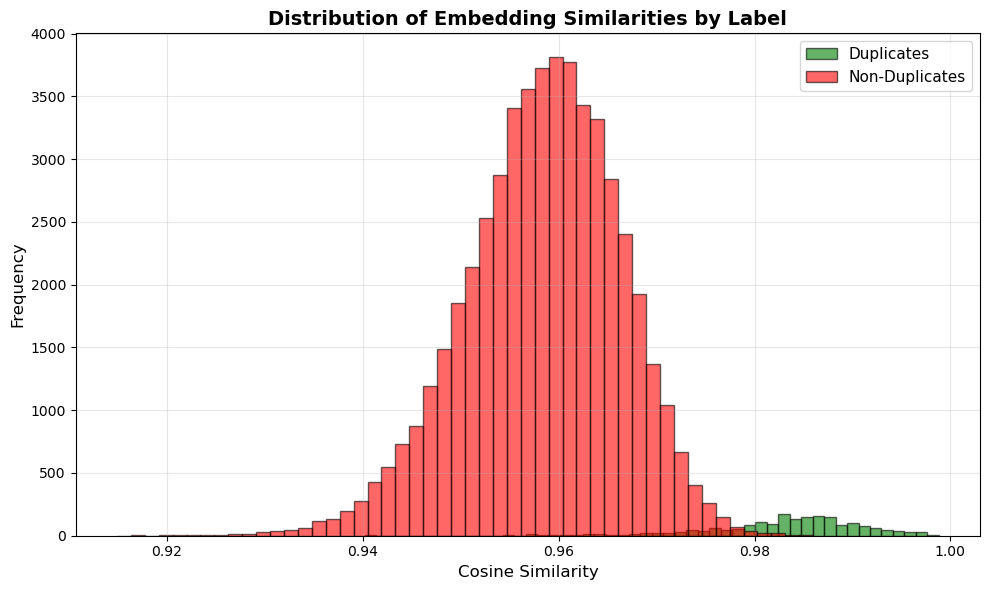

In [210]:
# Compute similarities if not already done
if 'similarity' not in train_last_name_pairs.columns:
    train_embed_indexed = train_embed.set_index('id')
    
    def get_sim(id1, id2):
        try:
            vec1 = train_embed_indexed.loc[id1].values
            vec2 = train_embed_indexed.loc[id2].values
            return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
        except:
            return np.nan
    
    train_last_name_pairs['similarity'] = train_last_name_pairs.apply(
        lambda row: get_sim(row['id1'], row['id2']),
        axis=1
    )

# Plot histogram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Separate by label
dup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 1]['similarity']
ndup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 0]['similarity']

# Plot histograms
ax.hist(dup_sims.dropna(), bins=50, alpha=0.6, label='Duplicates', color='green', edgecolor='black')
ax.hist(ndup_sims.dropna(), bins=50, alpha=0.6, label='Non-Duplicates', color='red', edgecolor='black')

ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Embedding Similarities by Label', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [219]:
def evaluate_model(ids_data, pairs_data, vocab_size=38, embed_dim=32, num_filters=128, 
                   kernel_sizes=(3, 4, 5), dropout=0.3, output_dim=128, thresholds=None):
    """
    Evaluate embedding model with given parameters.
    
    Parameters:
    -----------
    ids_data : pd.DataFrame
        DataFrame with columns: id, first_name, middle_name, last_name, age, sex
    pairs_data : pd.DataFrame
        DataFrame with columns: id1, id2, label (1 for duplicate, 0 for non-duplicate)
    vocab_size : int
        Vocabulary size for character mapping
    embed_dim : int
        Character embedding dimension
    num_filters : int
        Number of CNN filters
    kernel_sizes : tuple
        Kernel sizes for CNN
    dropout : float
        Dropout rate
    output_dim : int
        Output embedding dimension
    thresholds : list
        Thresholds to evaluate (default: [0.92, 0.94, 0.96, 0.97, 0.975, 0.98, 0.99])
    
    Returns:
    --------
    dict with keys:
        - 'embeddings': Generated embeddings dataframe
        - 'similarities': Dataframe with pairs and their similarity scores
        - 'metrics_df': Metrics at each threshold
        - 'best_f1': Best F1 score
        - 'best_threshold': Threshold with best F1
    """
    if thresholds is None:
        thresholds = [0.92, 0.94, 0.96, 0.97, 0.975, 0.98, 0.99]
    
    print("=" * 60)
    print(f"Model Configuration:")
    print(f"  vocab_size={vocab_size}, embed_dim={embed_dim}")
    print(f"  num_filters={num_filters}, kernel_sizes={kernel_sizes}")
    print(f"  dropout={dropout}, output_dim={output_dim}")
    print("=" * 60)
    
    # Create model
    model_eval = src.model.CharCNNEncoder(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_sizes=kernel_sizes,
        dropout=dropout,
        output_dim=output_dim
    )
    

    embeddings = src.model_utils.get_embeddings(ids_data, model_eval)
    embeddings_indexed = embeddings.set_index('id')
    
    
    # Compute similarities
   
    similarities = []
    for idx, row in pairs_data.iterrows():
        id1, id2 = row['id1'], row['id2']
        try:
            vec1 = embeddings_indexed.loc[id1].values
            vec2 = embeddings_indexed.loc[id2].values
            sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
            similarities.append(sim)
        except KeyError:
            similarities.append(np.nan)
    
    pairs_with_sim = pairs_data.copy()
    pairs_with_sim['similarity'] = similarities
    
    
    # Separate by label
    dup_sims = pairs_with_sim[pairs_with_sim['label'] == 1]['similarity'].dropna()
    ndup_sims = pairs_with_sim[pairs_with_sim['label'] == 0]['similarity'].dropna()
    
    
    # Evaluate thresholds
    
    metrics_results = []
    for thresh in thresholds:
        predictions = (pairs_with_sim['similarity'] > thresh).astype(int)
        actuals = pairs_with_sim['label'].astype(int)
        
        tn, fp, fn, tp = confusion_matrix(actuals, predictions).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        
        metrics_results.append({
            'Threshold': thresh,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Accuracy': accuracy,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'TN': tn
        })
    
    metrics_df = pd.DataFrame(metrics_results)
    best_f1_idx = metrics_df['F1'].idxmax()
    best_f1 = metrics_df.loc[best_f1_idx, 'F1']
    best_threshold = metrics_df.loc[best_f1_idx, 'Threshold']
    
    print(f"\n   Best F1: {best_f1:.4f} at threshold {best_threshold:.3f}")
    
    # Create visualizations
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Histogram
    ax1.hist(dup_sims, bins=50, alpha=0.6, label='Duplicates', color='green', edgecolor='black')
    ax1.hist(ndup_sims, bins=50, alpha=0.6, label='Non-Duplicates', color='red', edgecolor='black')
    ax1.set_xlabel('Cosine Similarity', fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title('Distribution of Embedding Similarities', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Precision-Recall Curve
    precisions_pr, recalls_pr, _ = precision_recall_curve(
        pairs_with_sim['label'].astype(int),
        pairs_with_sim['similarity']
    )
    ax2.plot(recalls_pr, precisions_pr, linewidth=2, color='blue')
    ax2.scatter(metrics_df['Recall'], metrics_df['Precision'], c=metrics_df['Threshold'], 
                cmap='viridis', s=100, zorder=5)
    ax2.set_xlabel('Recall', fontsize=11)
    ax2.set_ylabel('Precision', fontsize=11)
    ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # F1 vs Threshold
    ax3.plot(metrics_df['Threshold'], metrics_df['F1'], 'o-', linewidth=2, 
             markersize=8, label='F1', color='blue')
    ax3.plot(metrics_df['Threshold'], metrics_df['Precision'], 's-', linewidth=2, 
             markersize=6, label='Precision', color='orange')
    ax3.plot(metrics_df['Threshold'], metrics_df['Recall'], '^-', linewidth=2, 
             markersize=6, label='Recall', color='green')
    ax3.axvline(best_threshold, color='red', linestyle='--', alpha=0.7, label='Best F1')
    ax3.set_xlabel('Threshold', fontsize=11)
    ax3.set_ylabel('Score', fontsize=11)
    ax3.set_title('Metrics vs Similarity Threshold', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Confusion Matrix at best threshold
    best_preds = (pairs_with_sim['similarity'] > best_threshold).astype(int)
    best_cm = confusion_matrix(pairs_with_sim['label'].astype(int), best_preds)
    sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
                xticklabels=['Non-Dup', 'Dup'], yticklabels=['Non-Dup', 'Dup'])
    ax4.set_ylabel('Actual', fontsize=11)
    ax4.set_xlabel('Predicted', fontsize=11)
    ax4.set_title(f'Confusion Matrix (threshold={best_threshold:.3f}, F1={best_f1:.4f})', 
                  fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n" + "=" * 60)
    print("THRESHOLD EVALUATION RESULTS:")
    print("=" * 60)
    print(metrics_df.to_string(index=False))
    print("=" * 60)
    
    return {
        'embeddings': embeddings,
        'similarities': pairs_with_sim,
        'metrics_df': metrics_df,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'dup_sims': dup_sims,
        'ndup_sims': ndup_sims
    }

In [212]:
# Import required visualization library
import seaborn as sns

Running grid search across embed_dim and output_dim...

[1/16] Testing embed_dim=16, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.5221 at threshold 0.990


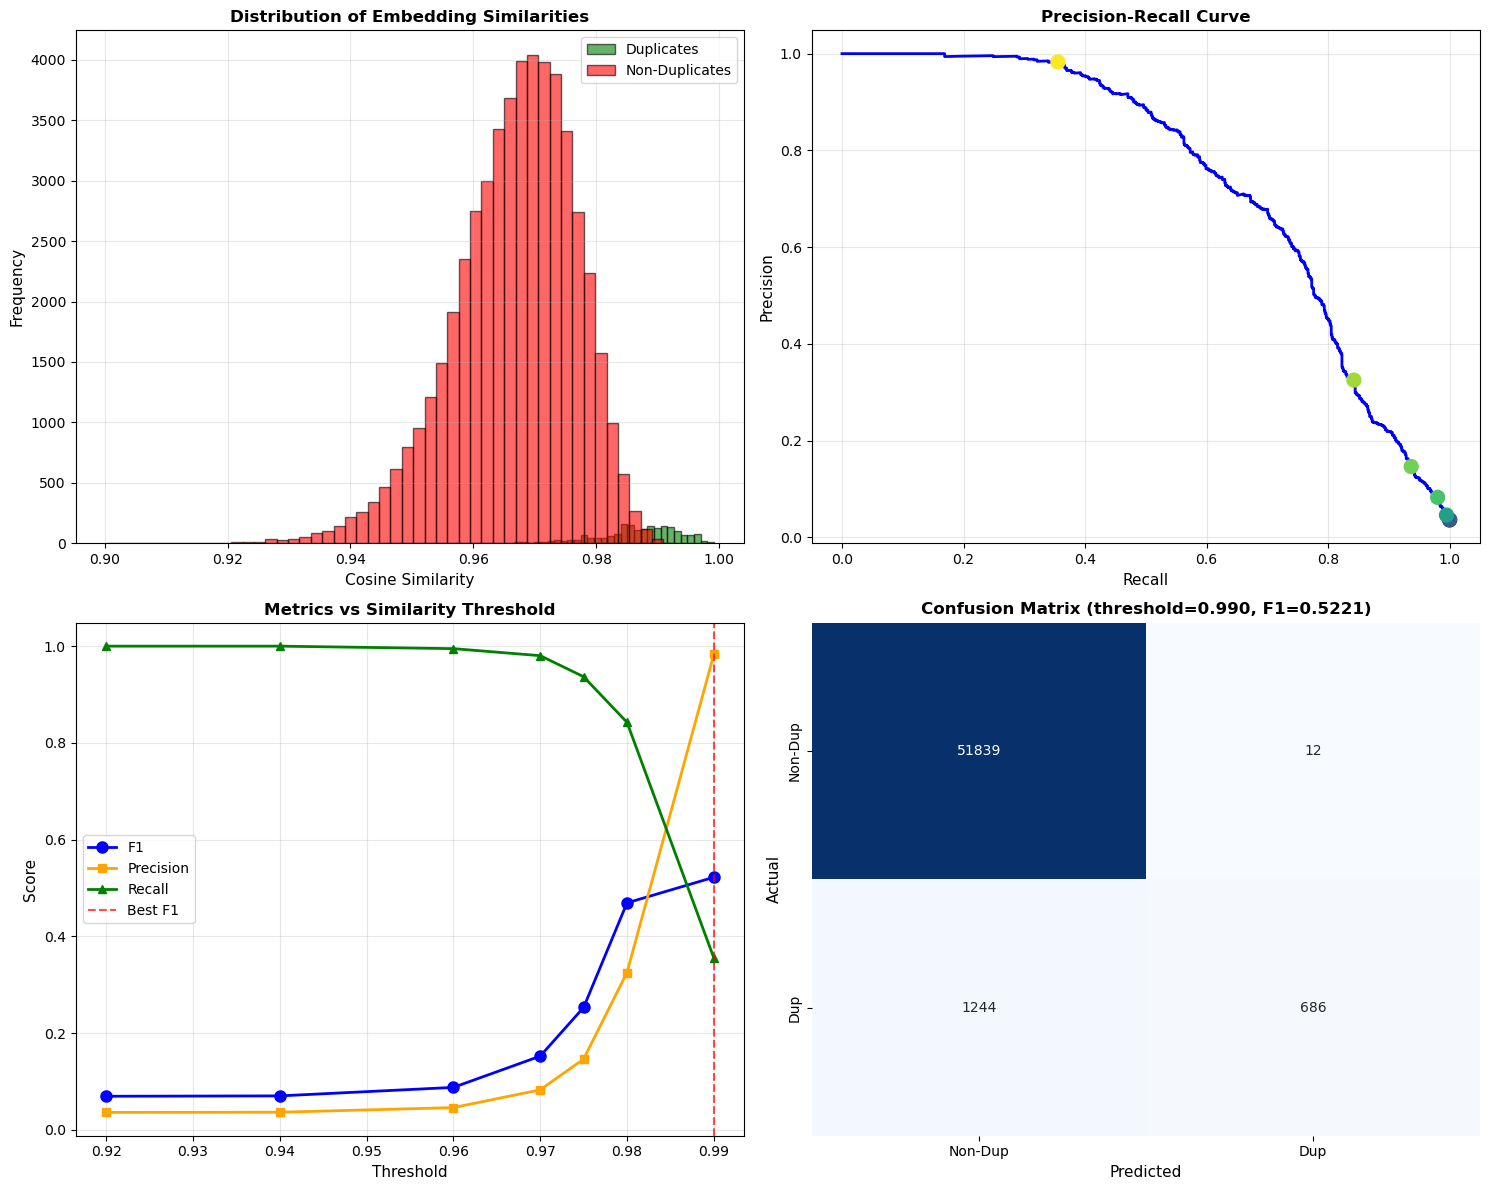


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035898 1.000000 0.069307  0.036202 1930 51834    0    17
     0.940   0.036298 1.000000 0.070053  0.047229 1930 51241    0   610
     0.960   0.045828 0.994819 0.087619  0.256503 1920 39976   10 11875
     0.970   0.082526 0.980311 0.152237  0.608189 1892 21034   38 30817
     0.975   0.146172 0.936788 0.252885  0.801361 1808 10561  122 41290
     0.980   0.325070 0.842487 0.469129  0.931574 1626  3376  304 48475
     0.990   0.982808 0.355440 0.522070  0.976646  686    12 1244 51839
  ✓ Best F1: 0.5221 at threshold 0.990

[2/16] Testing embed_dim=16, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.7199 at threshold 0.980


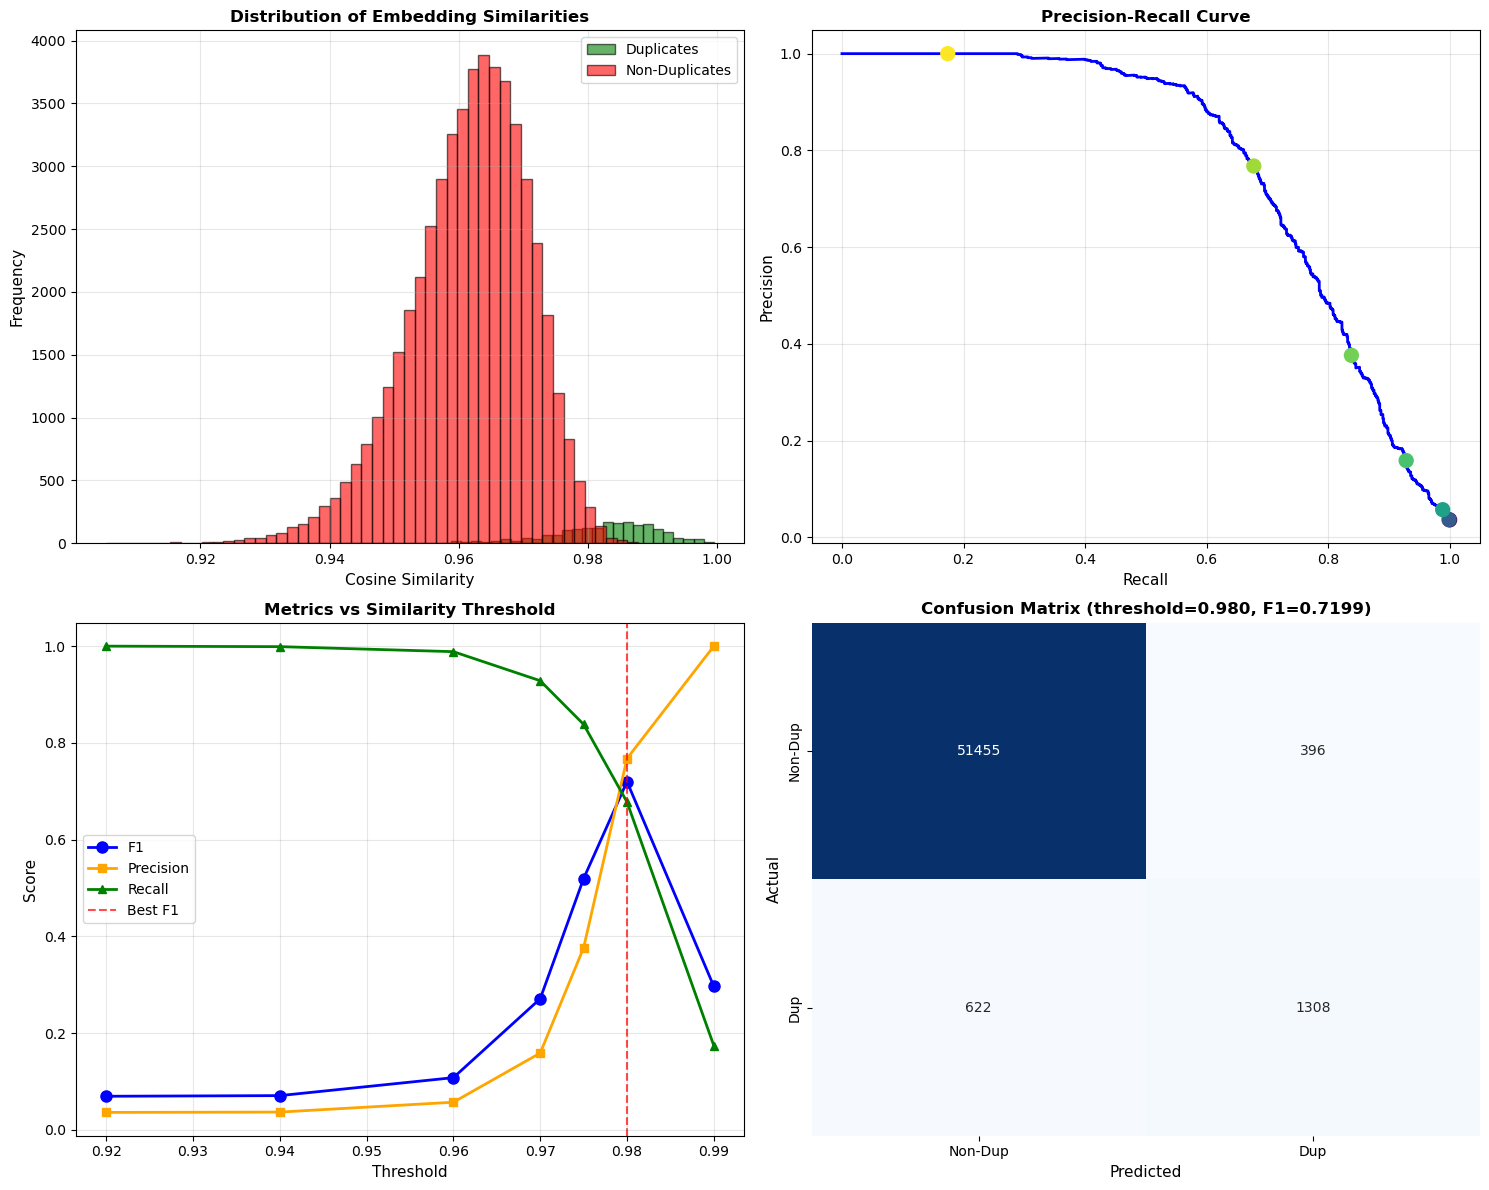


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035898 1.000000 0.069309  0.036221 1930 51833    0    18
     0.940   0.036602 0.998964 0.070616  0.056377 1928 50747    2  1104
     0.960   0.056991 0.988601 0.107769  0.412562 1908 31571   22 20280
     0.970   0.158584 0.928497 0.270899  0.820643 1792  9508  138 42343
     0.975   0.376192 0.838342 0.519339  0.944311 1618  2683  312 49168
     0.980   0.767606 0.677720 0.719868  0.981071 1308   396  622 51455
     0.990   1.000000 0.174093 0.296558  0.970361  336     0 1594 51851
  ✓ Best F1: 0.7199 at threshold 0.980

[3/16] Testing embed_dim=16, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.7333 at threshold 0.980


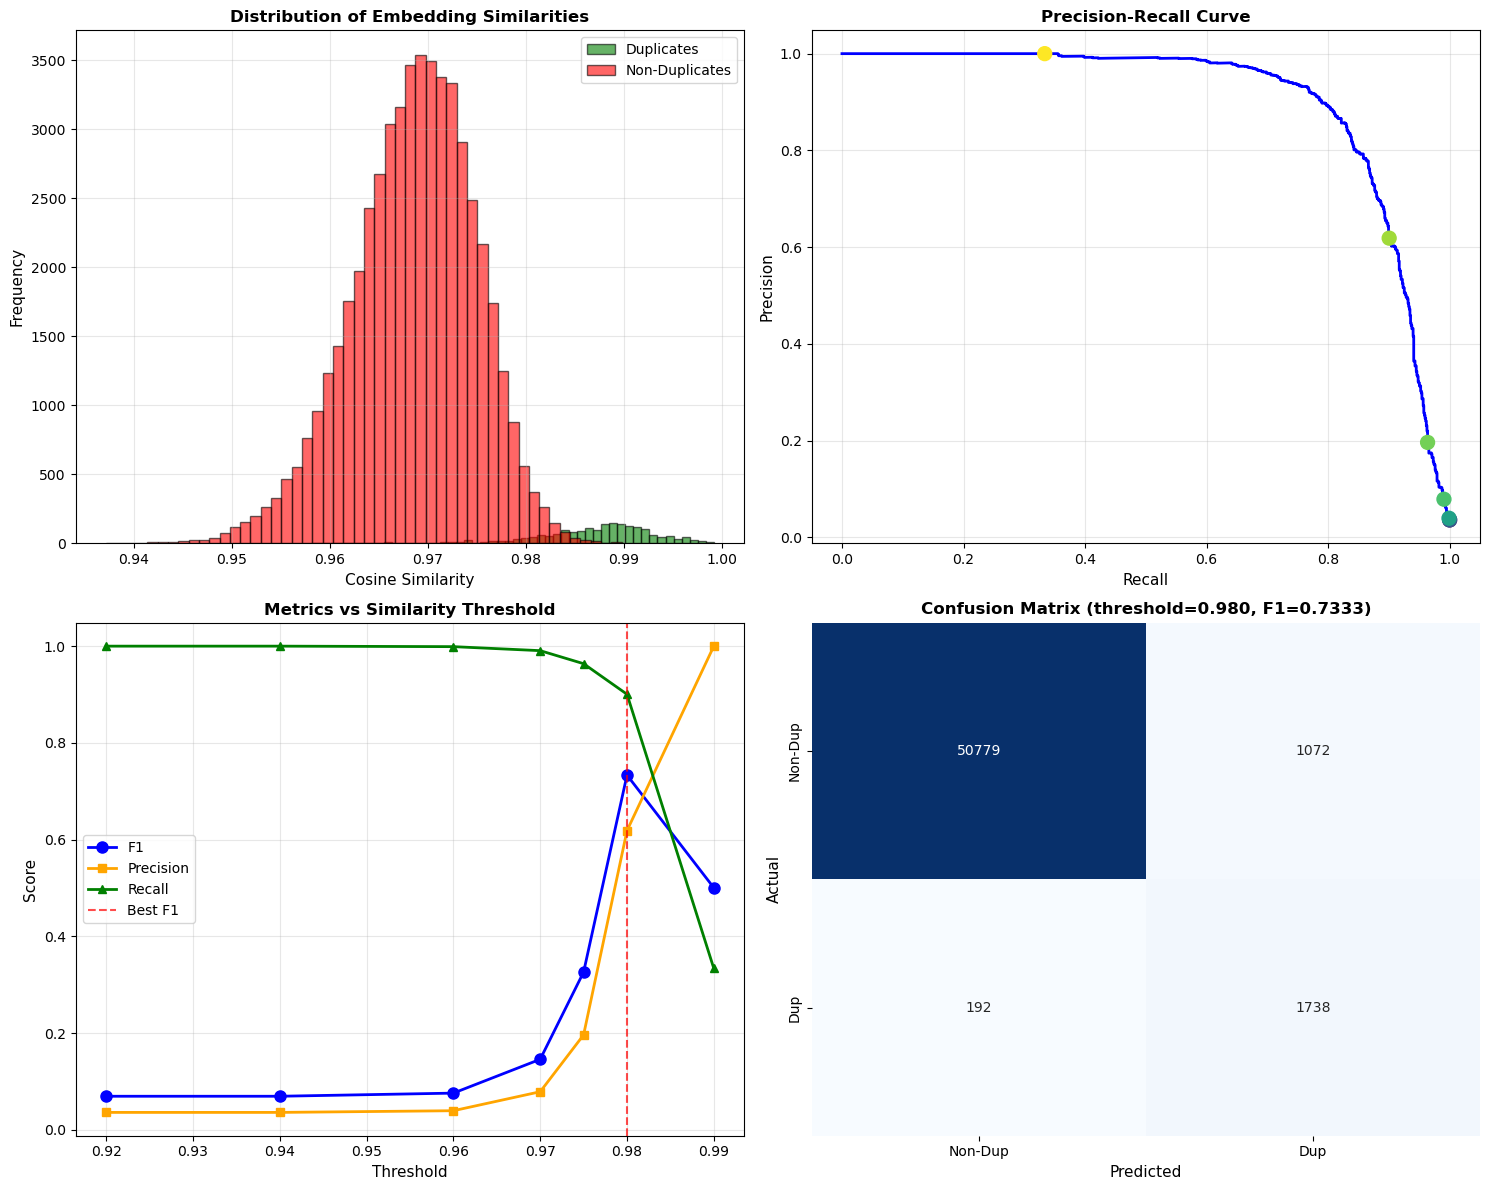


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035892 1.000000 0.069297  0.036054 1930 51842    0     9
     0.960   0.039375 0.998964 0.075764  0.125360 1928 47037    2  4814
     0.970   0.078641 0.990674 0.145715  0.583143 1912 22401   18 29450
     0.975   0.196182 0.963731 0.326001  0.856994 1860  7621   70 44230
     0.980   0.618505 0.900518 0.733333  0.976497 1738  1072  192 50779
     0.990   1.000000 0.333679 0.500389  0.976088  644     0 1286 51851
  ✓ Best F1: 0.7333 at threshold 0.980

[4/16] Testing embed_dim=16, output_dim=256
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=256

   Best F1: 0.8519 at threshold 0.975


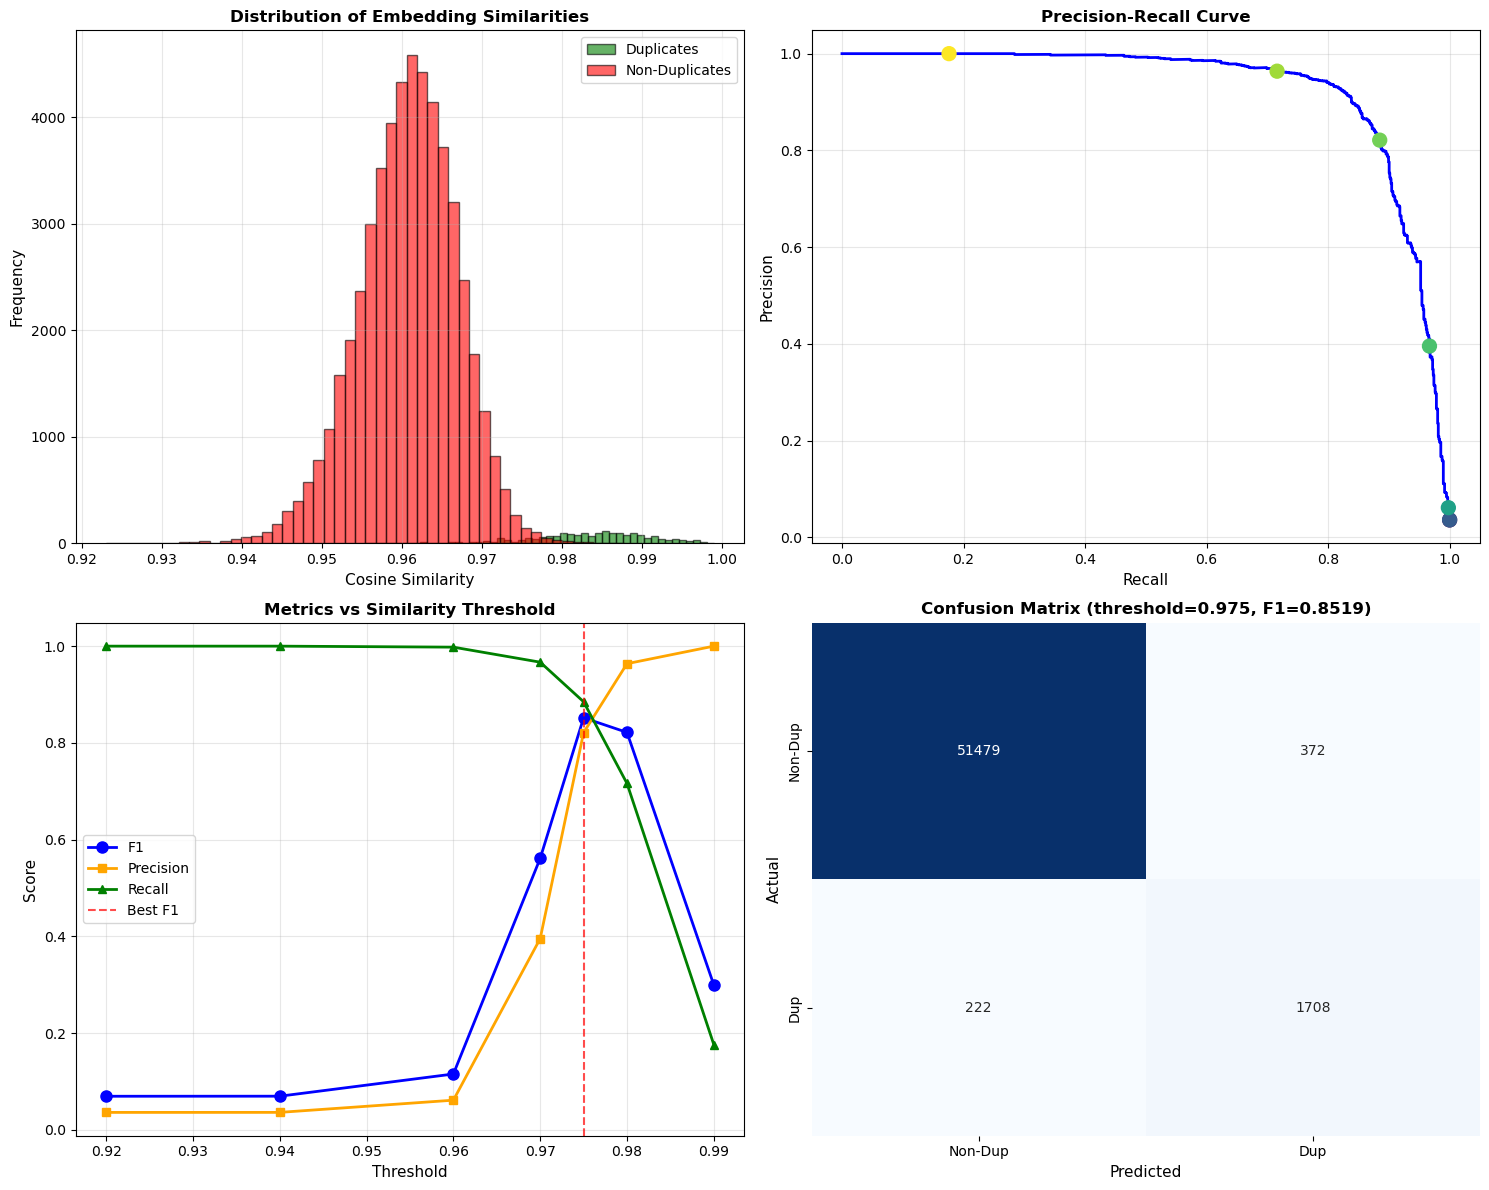


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035956 1.000000 0.069417  0.037839 1930 51746    0   105
     0.960   0.061172 0.997927 0.115278  0.450308 1926 29559    4 22292
     0.970   0.395339 0.966839 0.561203  0.945743 1866  2854   64 48997
     0.975   0.821154 0.884974 0.851870  0.988955 1708   372  222 51479
     0.980   0.963738 0.716062 0.821641  0.988844 1382    52  548 51799
     0.990   1.000000 0.176166 0.299559  0.970436  340     0 1590 51851
  ✓ Best F1: 0.8519 at threshold 0.975

[5/16] Testing embed_dim=32, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.6519 at threshold 0.990


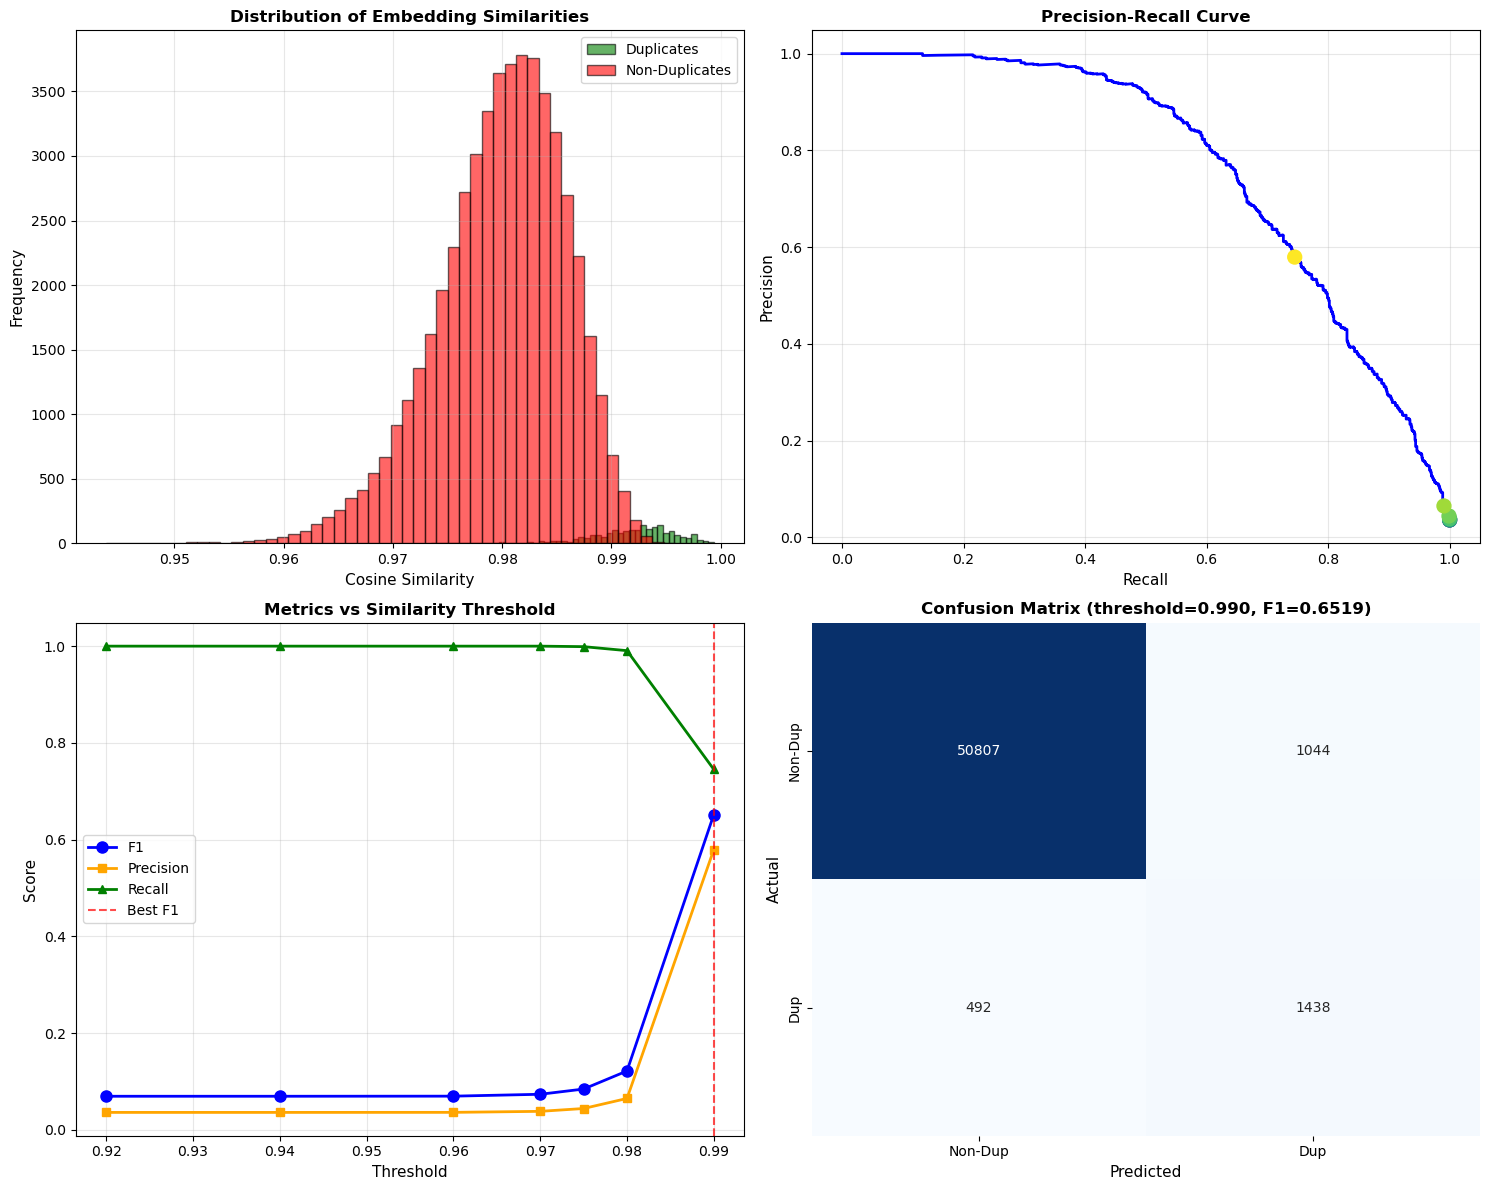


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP  FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851   0     0
     0.940   0.035886 1.000000 0.069286  0.035886 1930 51851   0     0
     0.960   0.035995 1.000000 0.069488  0.038898 1930 51689   0   162
     0.970   0.038091 1.000000 0.073387  0.093769 1930 48738   0  3113
     0.975   0.043944 0.998964 0.084185  0.220022 1928 41946   2  9905
     0.980   0.064750 0.990674 0.121555  0.486157 1912 27617  18 24234
     0.990   0.579371 0.745078 0.651859  0.971440 1438  1044 492 50807
  ✓ Best F1: 0.6519 at threshold 0.990

[6/16] Testing embed_dim=32, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.8030 at threshold 0.980


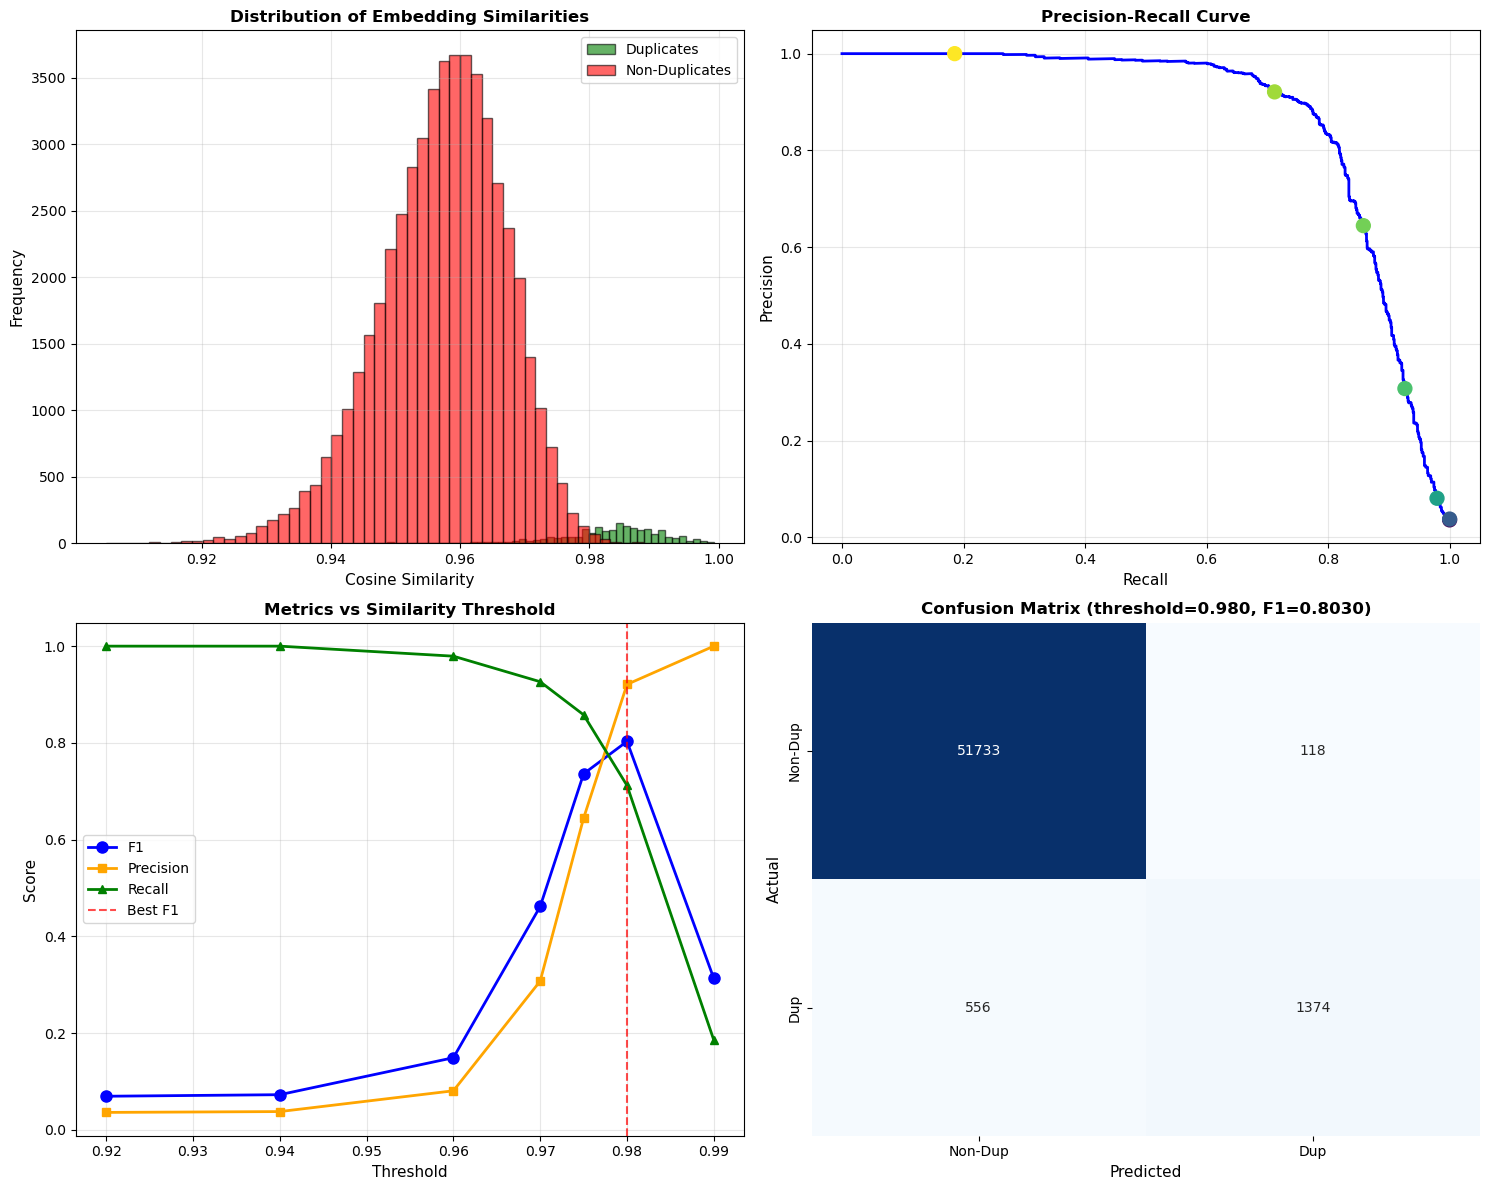


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035928 1.000000 0.069363  0.037039 1930 51789    0    62
     0.940   0.037647 1.000000 0.072562  0.082650 1930 49336    0  2515
     0.960   0.080635 0.979275 0.149001  0.598576 1890 21549   40 30302
     0.970   0.307481 0.926425 0.461717  0.922482 1788  4027  142 47824
     0.975   0.644358 0.858031 0.736000  0.977910 1656   914  274 50937
     0.980   0.920912 0.711917 0.803039  0.987468 1374   118  556 51733
     0.990   1.000000 0.185492 0.312937  0.970770  358     0 1572 51851
  ✓ Best F1: 0.8030 at threshold 0.980

[7/16] Testing embed_dim=32, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.8792 at threshold 0.980


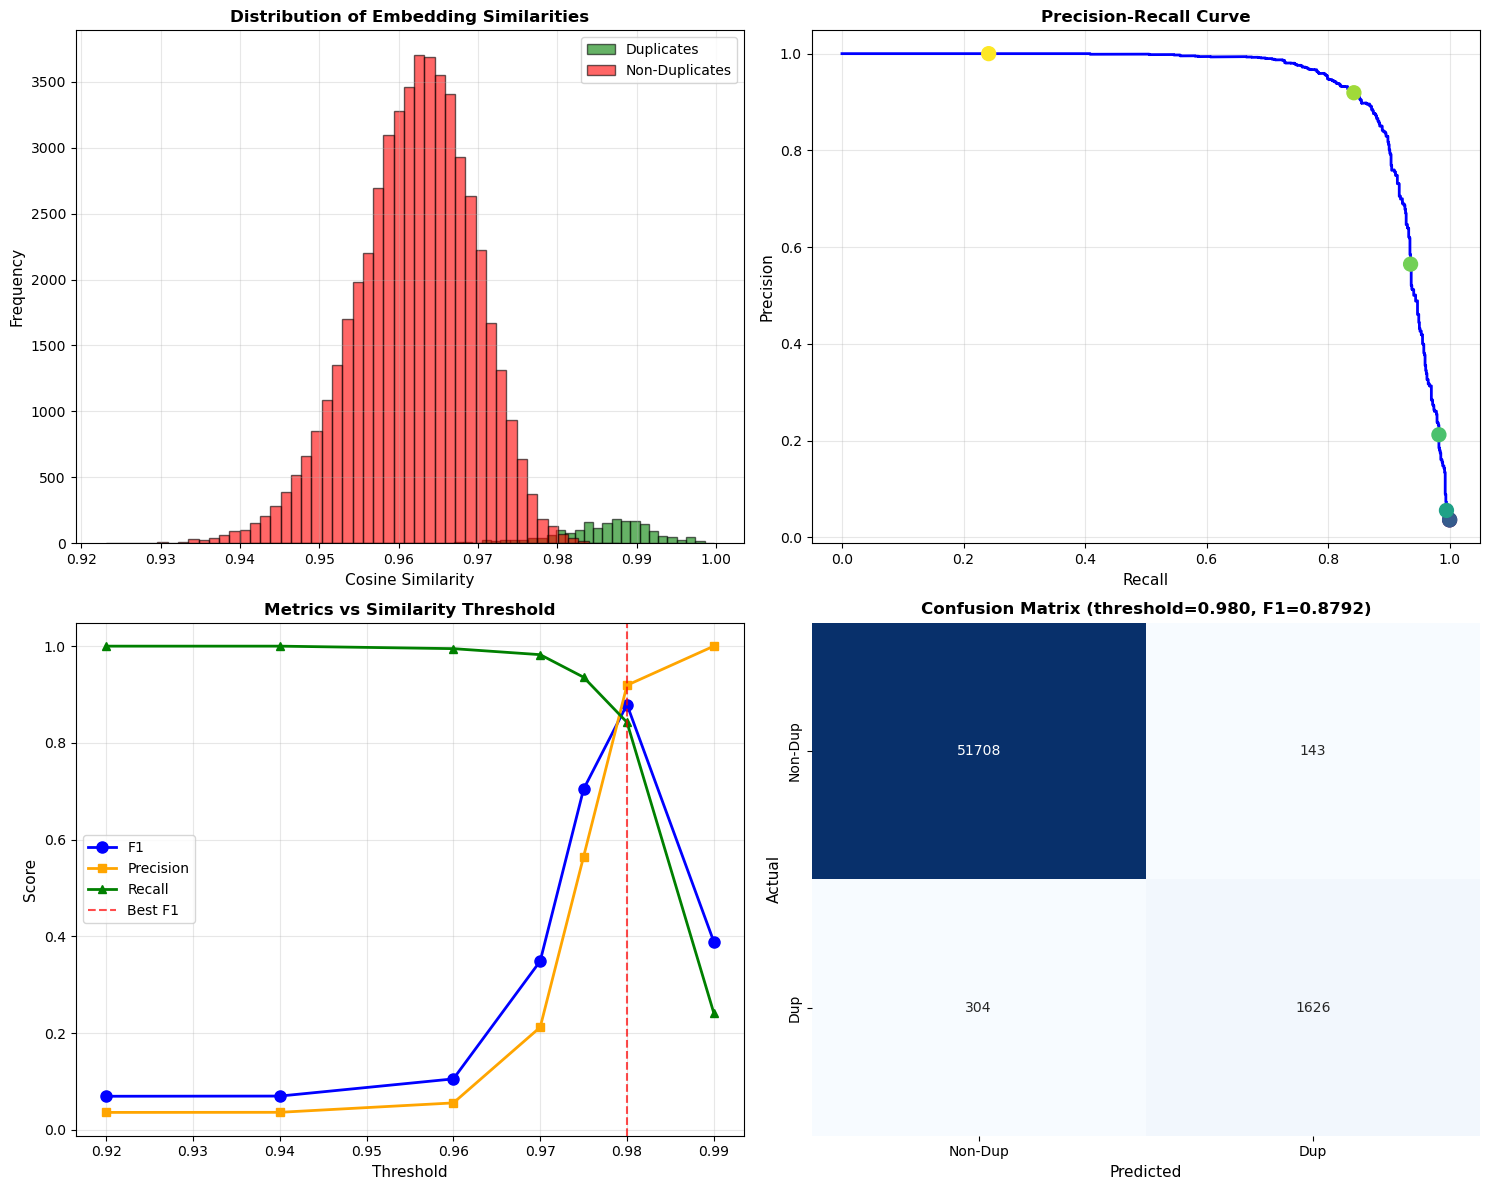


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.036086 1.000000 0.069659  0.041427 1930 51553    0   298
     0.960   0.055533 0.994819 0.105194  0.392648 1920 32654   10 19197
     0.970   0.212009 0.982383 0.348754  0.868336 1896  7047   34 44804
     0.975   0.564728 0.935751 0.704368  0.971812 1806  1392  124 50459
     0.980   0.919163 0.842487 0.879157  0.991689 1626   143  304 51708
     0.990   1.000000 0.241451 0.388982  0.972778  466     0 1464 51851
  ✓ Best F1: 0.8792 at threshold 0.980

[8/16] Testing embed_dim=32, output_dim=256
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=256

   Best F1: 0.8870 at threshold 0.980


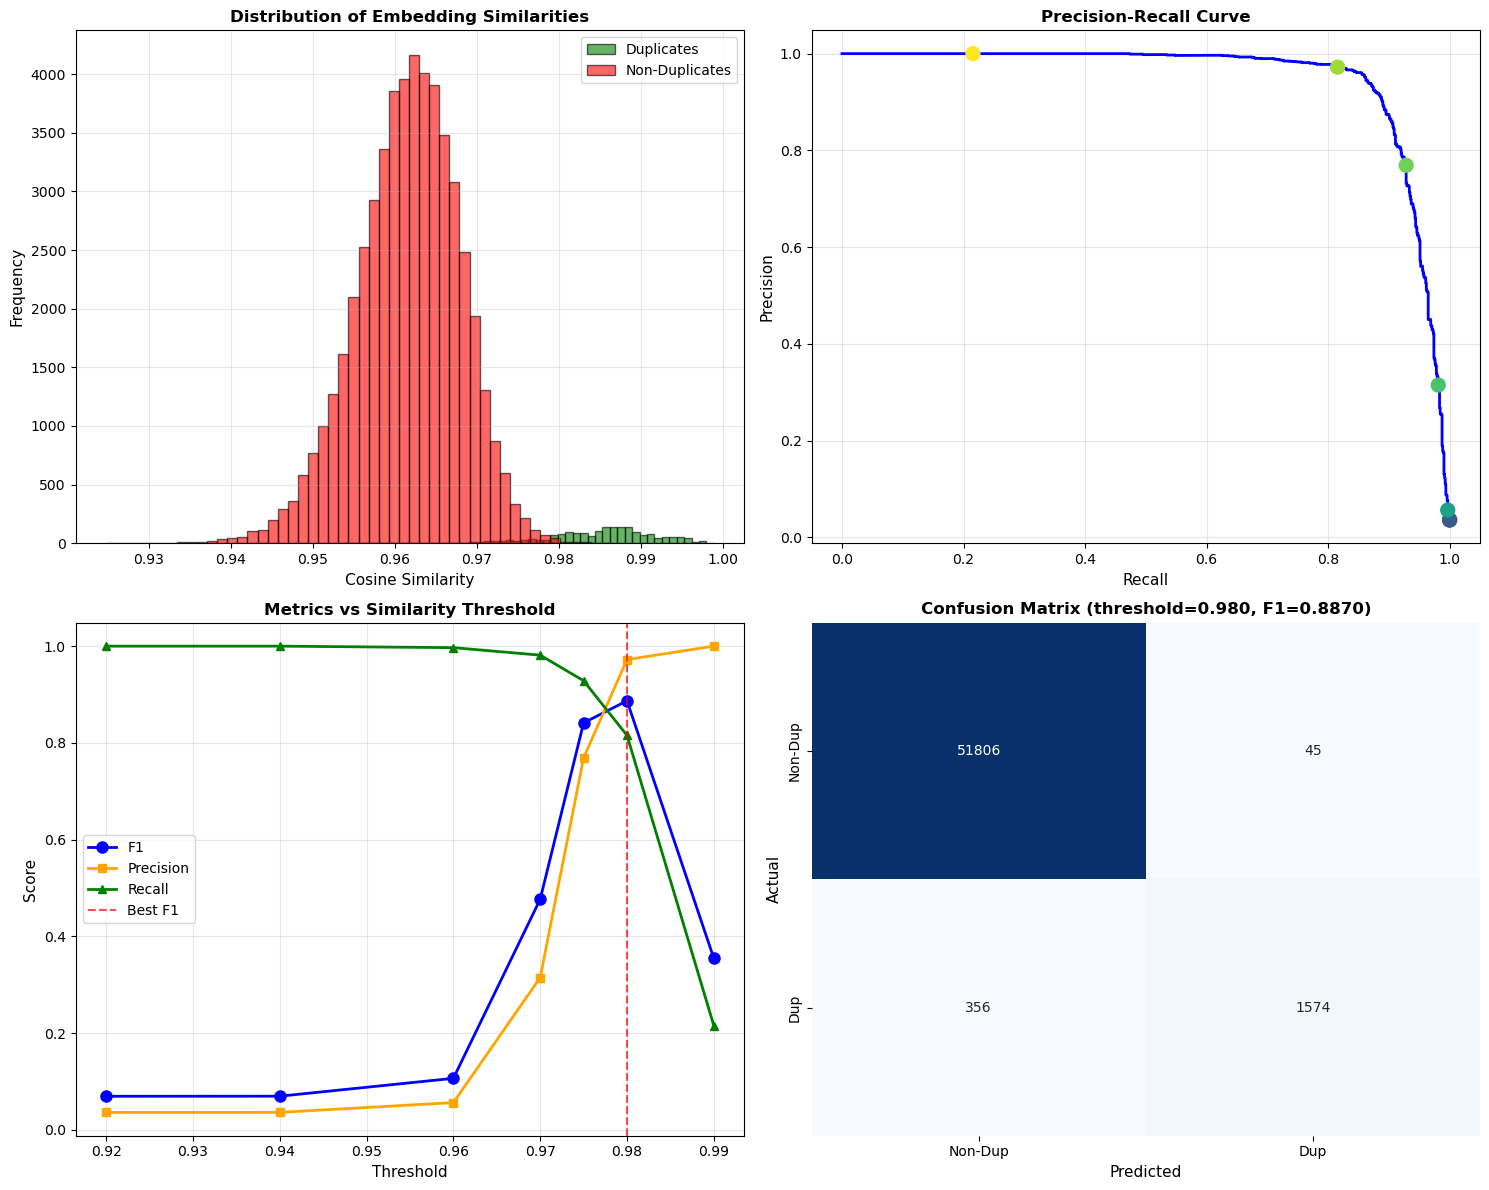


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035956 1.000000 0.069416  0.037820 1930 51747    0   104
     0.960   0.056185 0.996891 0.106375  0.398933 1924 32320    6 19531
     0.970   0.314722 0.981347 0.476598  0.922649 1894  4124   36 47727
     0.975   0.769099 0.928497 0.841315  0.987431 1792   538  138 51313
     0.980   0.972205 0.815544 0.887010  0.992544 1574    45  356 51806
     0.990   1.000000 0.215544 0.354646  0.971849  416     0 1514 51851
  ✓ Best F1: 0.8870 at threshold 0.980

[9/16] Testing embed_dim=48, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=48
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.5550 at threshold 0.990


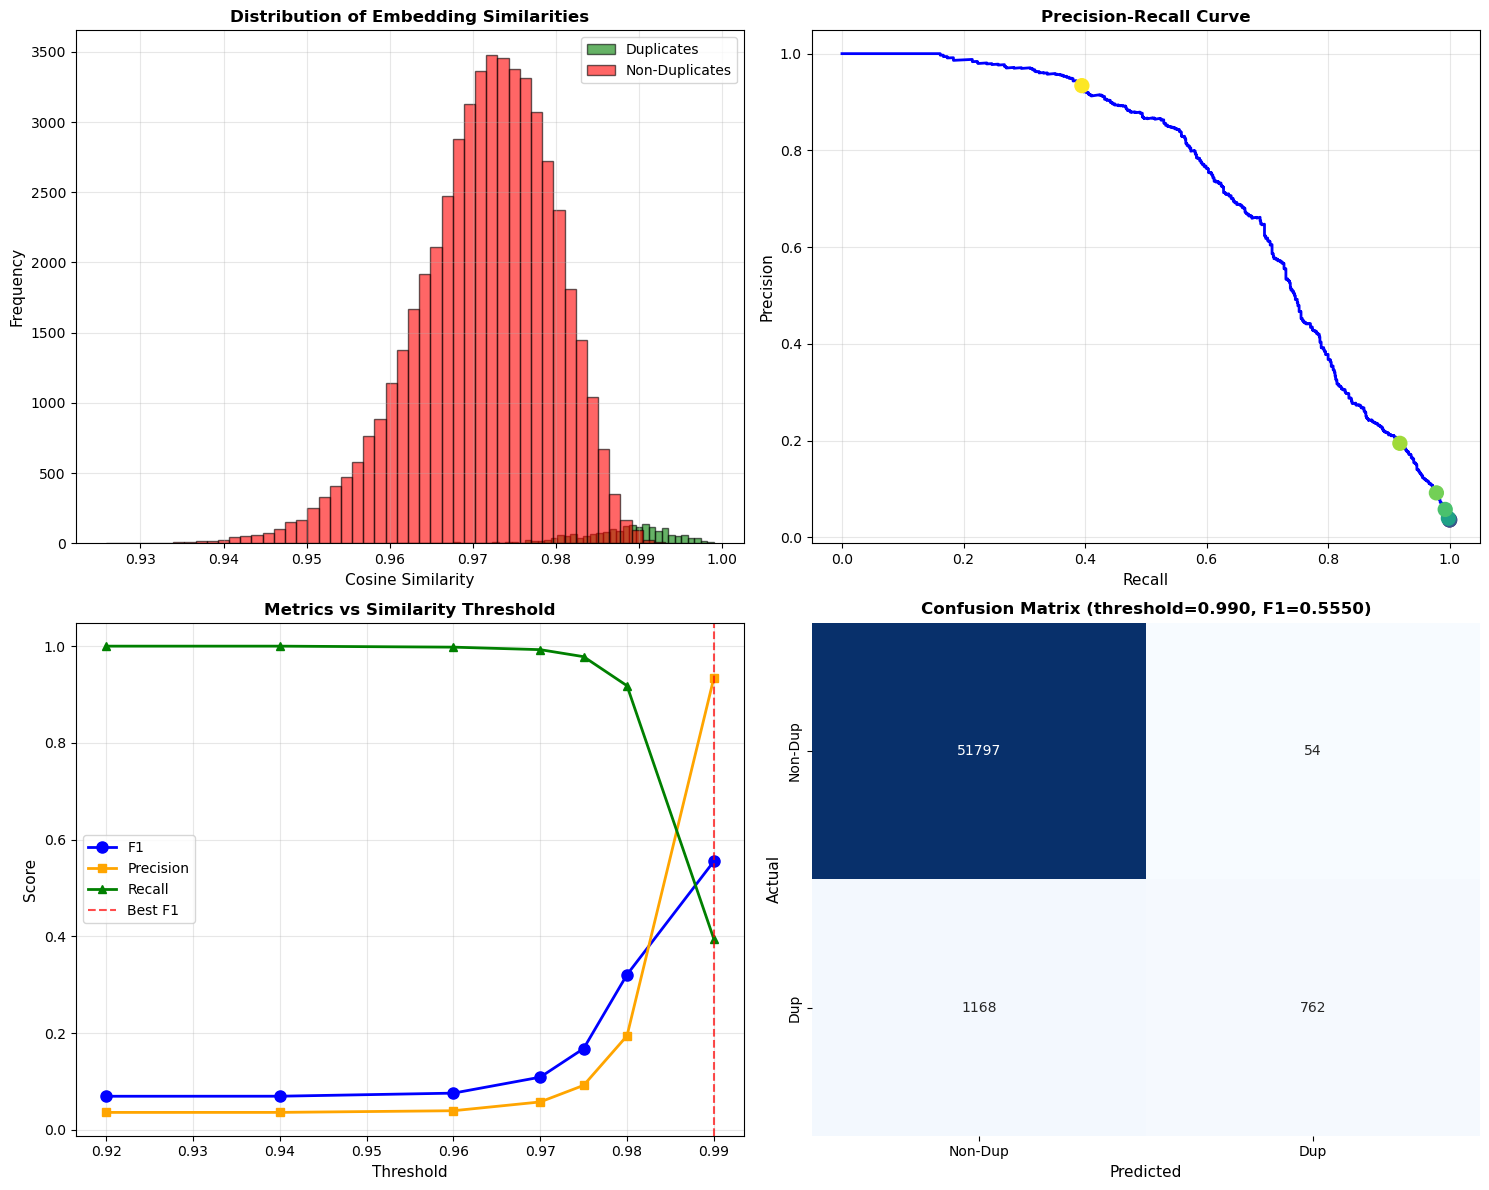


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035932 1.000000 0.069372  0.037169 1930 51782    0    69
     0.960   0.039358 0.997927 0.075728  0.125825 1926 47010    4  4841
     0.970   0.057522 0.992746 0.108743  0.416021 1916 31393   14 20458
     0.975   0.091793 0.978238 0.167837  0.651884 1888 18680   42 33171
     0.980   0.194256 0.918135 0.320666  0.860397 1772  7350  158 44501
     0.990   0.933824 0.394819 0.554989  0.977278  762    54 1168 51797
  ✓ Best F1: 0.5550 at threshold 0.990

[10/16] Testing embed_dim=48, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=48
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.7455 at threshold 0.980


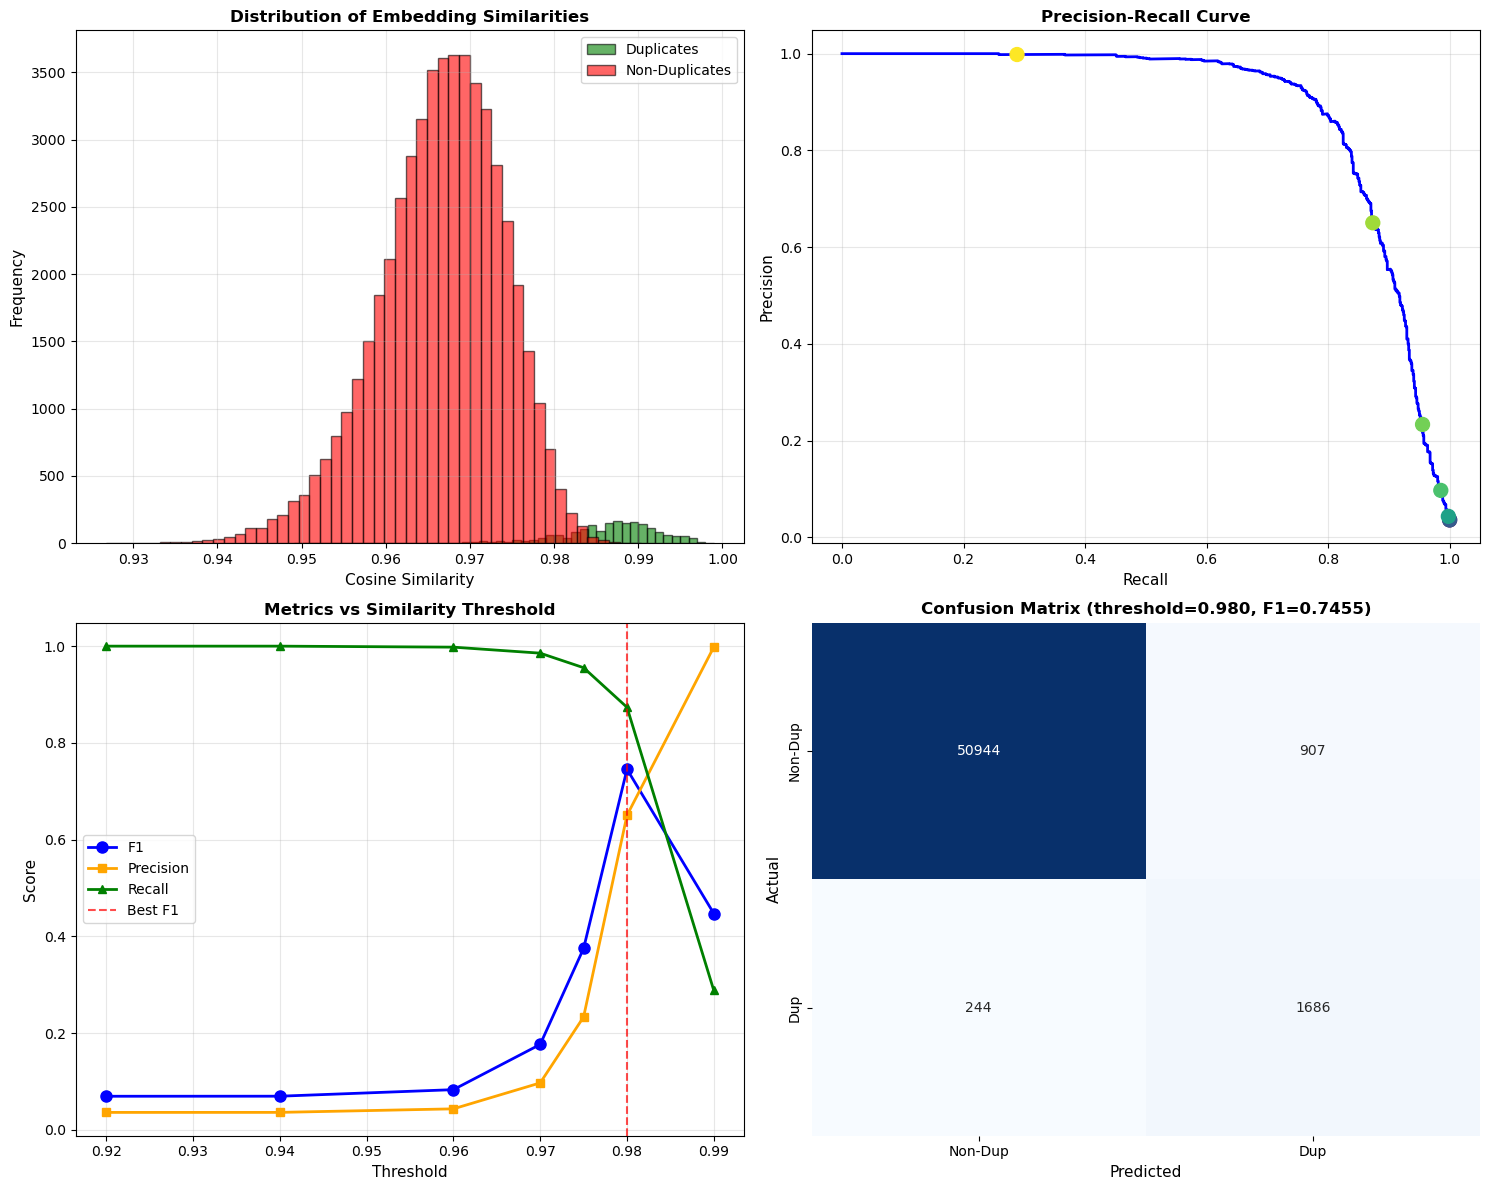


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035946 1.000000 0.069398  0.037560 1930 51761    0    90
     0.960   0.043258 0.997927 0.082921  0.207862 1926 42598    4  9253
     0.970   0.096893 0.985492 0.176438  0.669846 1902 17728   28 34123
     0.975   0.233270 0.955440 0.374987  0.885703 1844  6061   86 45790
     0.980   0.650212 0.873575 0.745523  0.978598 1686   907  244 50944
     0.990   0.998205 0.288083 0.447125  0.974433  556     1 1374 51850
  ✓ Best F1: 0.7455 at threshold 0.980

[11/16] Testing embed_dim=48, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=48
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.8423 at threshold 0.980


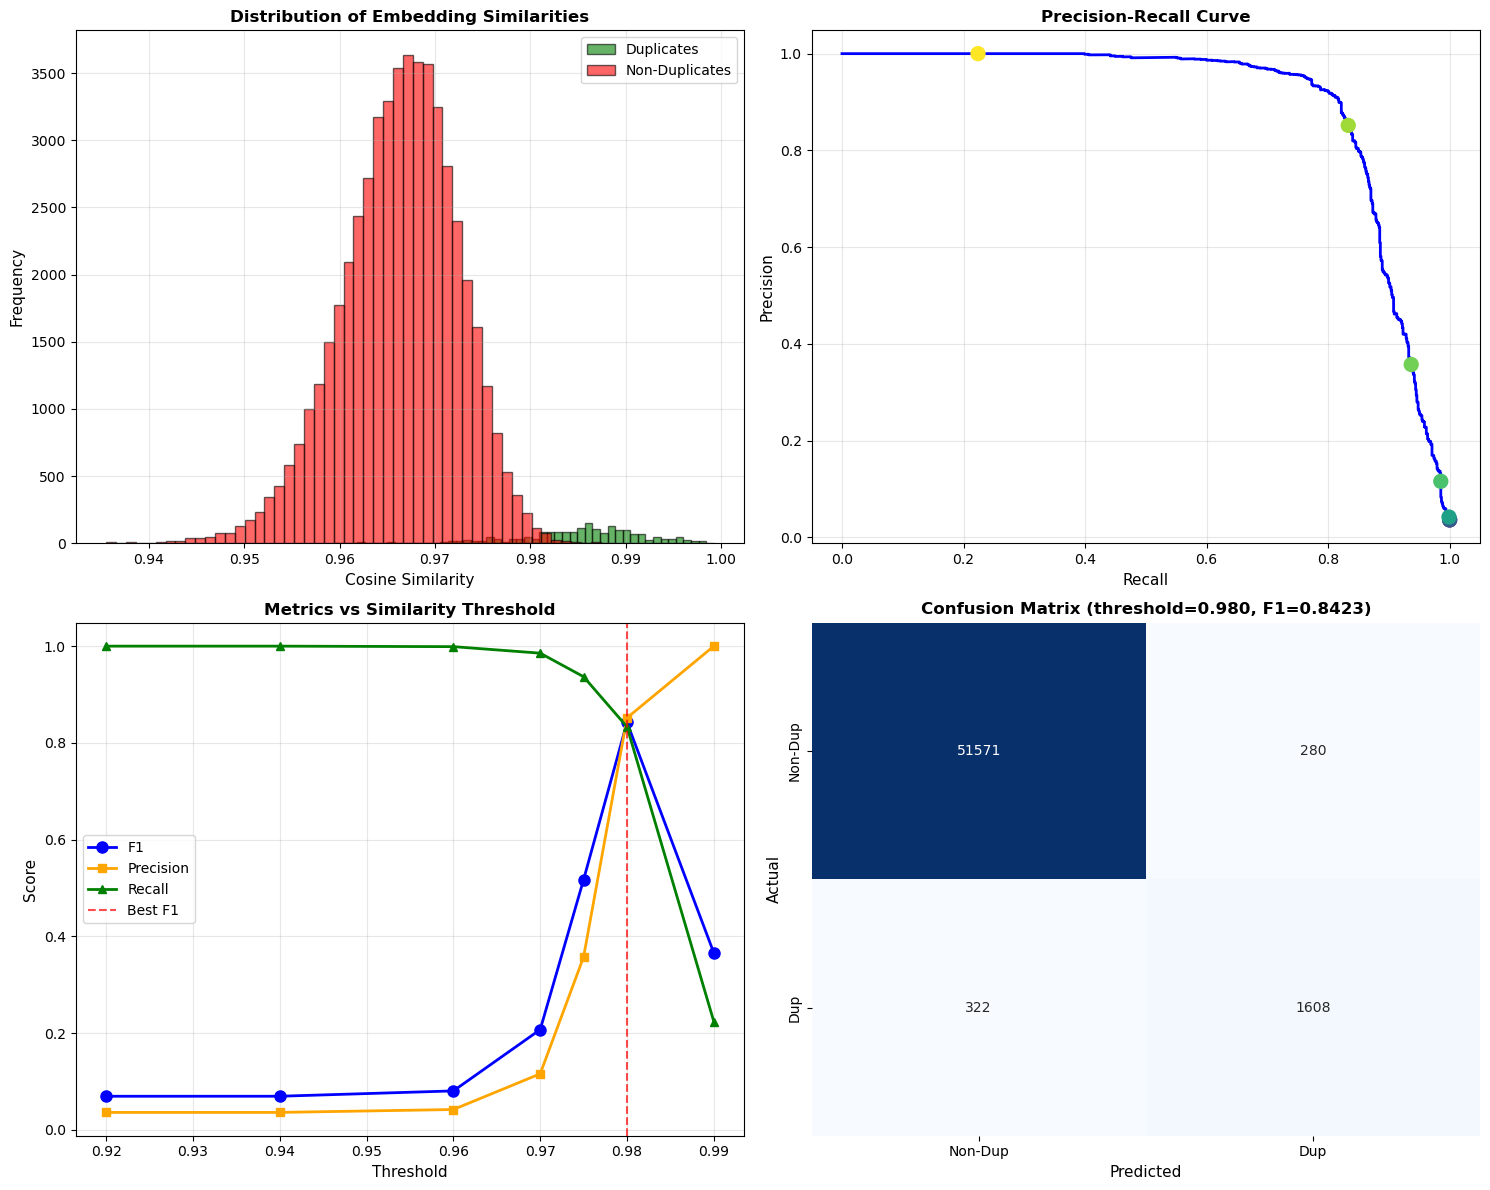


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035898 1.000000 0.069307  0.036202 1930 51834    0    17
     0.960   0.041865 0.998964 0.080362  0.179506 1928 44125    2  7726
     0.970   0.115693 0.985492 0.207077  0.729161 1902 14538   28 37313
     0.975   0.357242 0.936788 0.517236  0.937245 1808  3253  122 48598
     0.980   0.851695 0.833161 0.842326  0.988806 1608   280  322 51571
     0.990   1.000000 0.223834 0.365792  0.972146  432     0 1498 51851
  ✓ Best F1: 0.8423 at threshold 0.980

[12/16] Testing embed_dim=48, output_dim=256
Model Configuration:
  vocab_size=38, embed_dim=48
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=256

   Best F1: 0.8873 at threshold 0.980


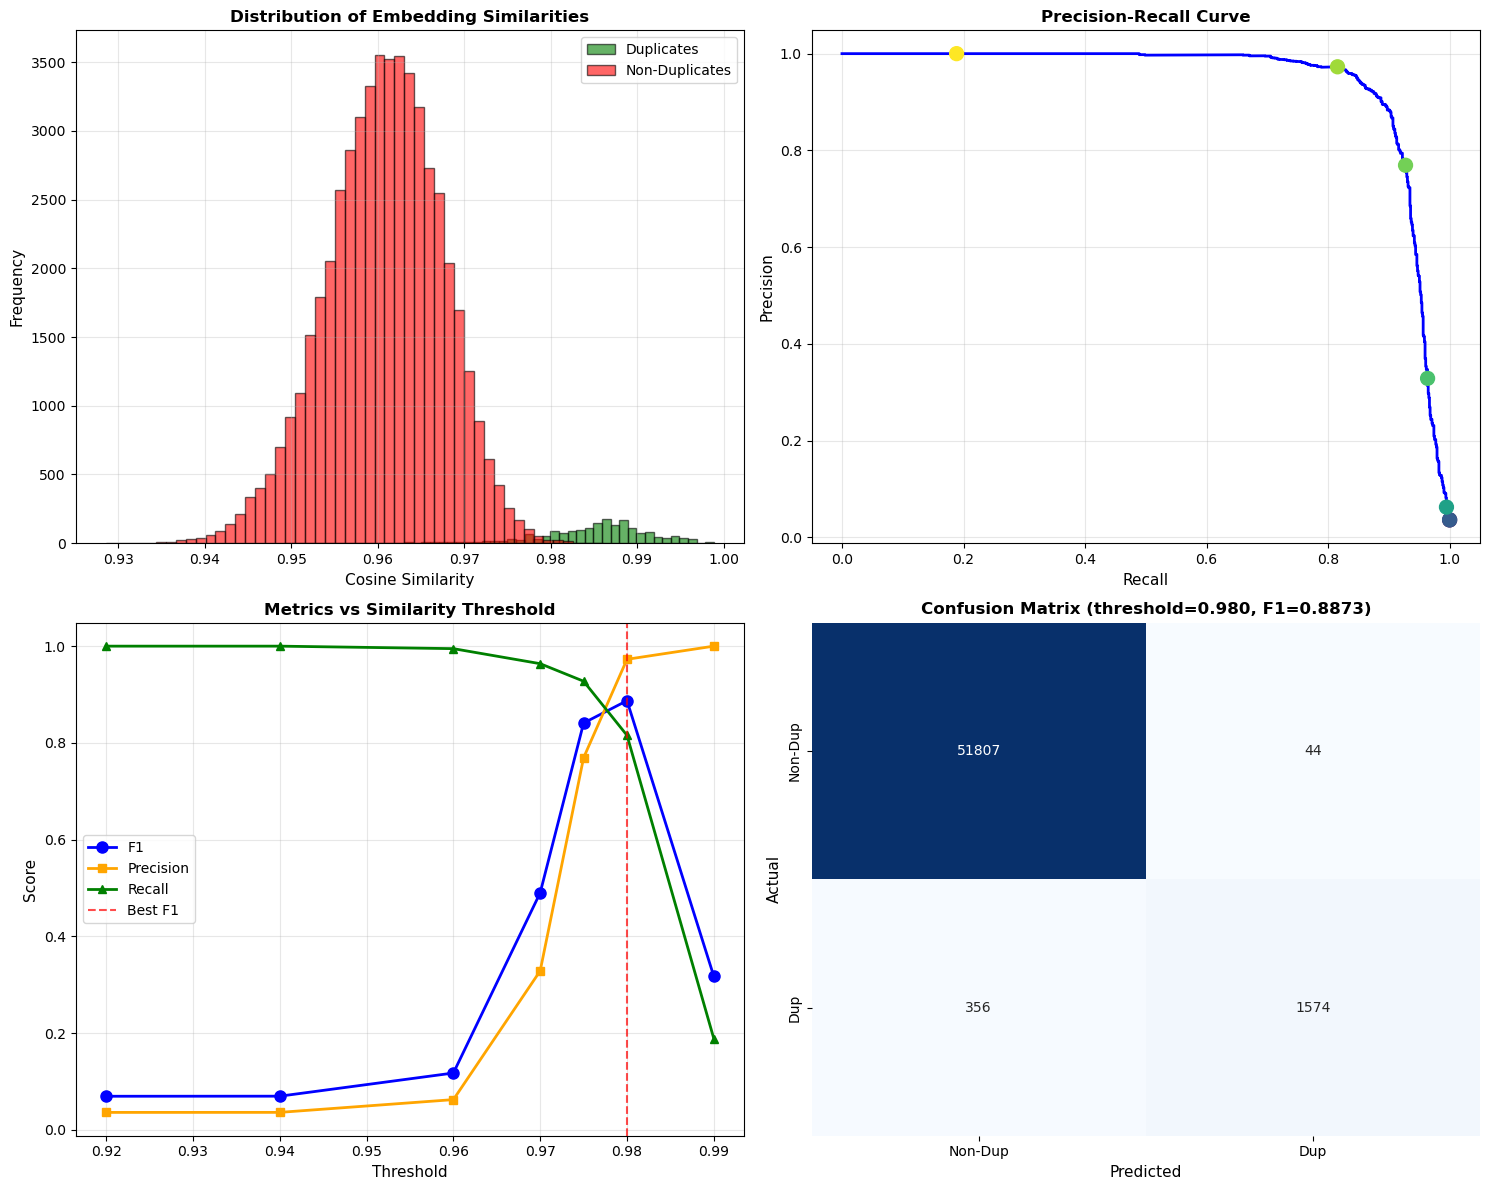


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035968 1.000000 0.069438  0.038155 1930 51729    0   122
     0.960   0.062344 0.994819 0.117334  0.462877 1920 28877   10 22974
     0.970   0.328564 0.963731 0.490054  0.928023 1860  3801   70 48050
     0.975   0.769231 0.927461 0.840968  0.987412 1790   537  140 51314
     0.980   0.972806 0.815544 0.887260  0.992562 1574    44  356 51807
     0.990   1.000000 0.188601 0.317350  0.970882  364     0 1566 51851
  ✓ Best F1: 0.8873 at threshold 0.980

[13/16] Testing embed_dim=64, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.7184 at threshold 0.980


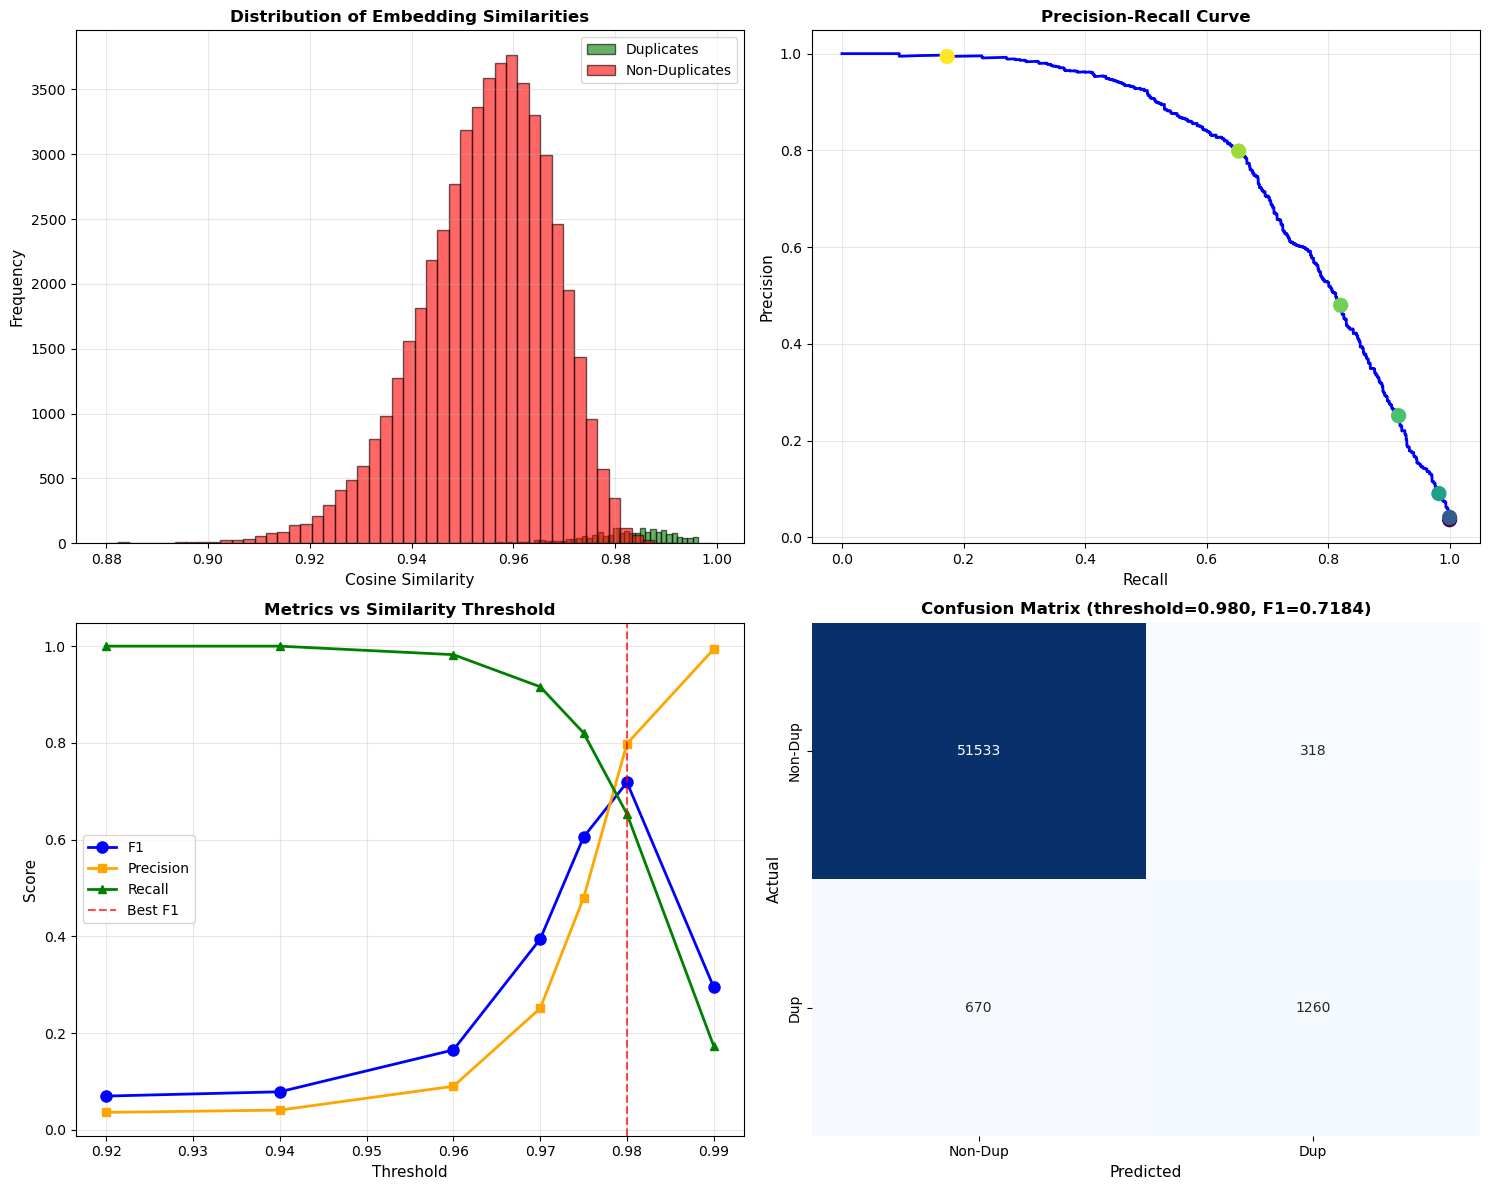


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.036314 1.000000 0.070084  0.047675 1930 51217    0   634
     0.940   0.041086 1.000000 0.078929  0.162437 1930 45045    0  6806
     0.960   0.090333 0.982383 0.165452  0.644354 1896 19093   34 32758
     0.970   0.251351 0.916062 0.394467  0.899072 1768  5266  162 46585
     0.975   0.479709 0.820725 0.605505  0.961622 1584  1718  346 50133
     0.980   0.798479 0.652850 0.718358  0.981629 1260   318  670 51533
     0.990   0.994048 0.173057 0.294793  0.970287  334     2 1596 51849
  ✓ Best F1: 0.7184 at threshold 0.980

[14/16] Testing embed_dim=64, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.8323 at threshold 0.980


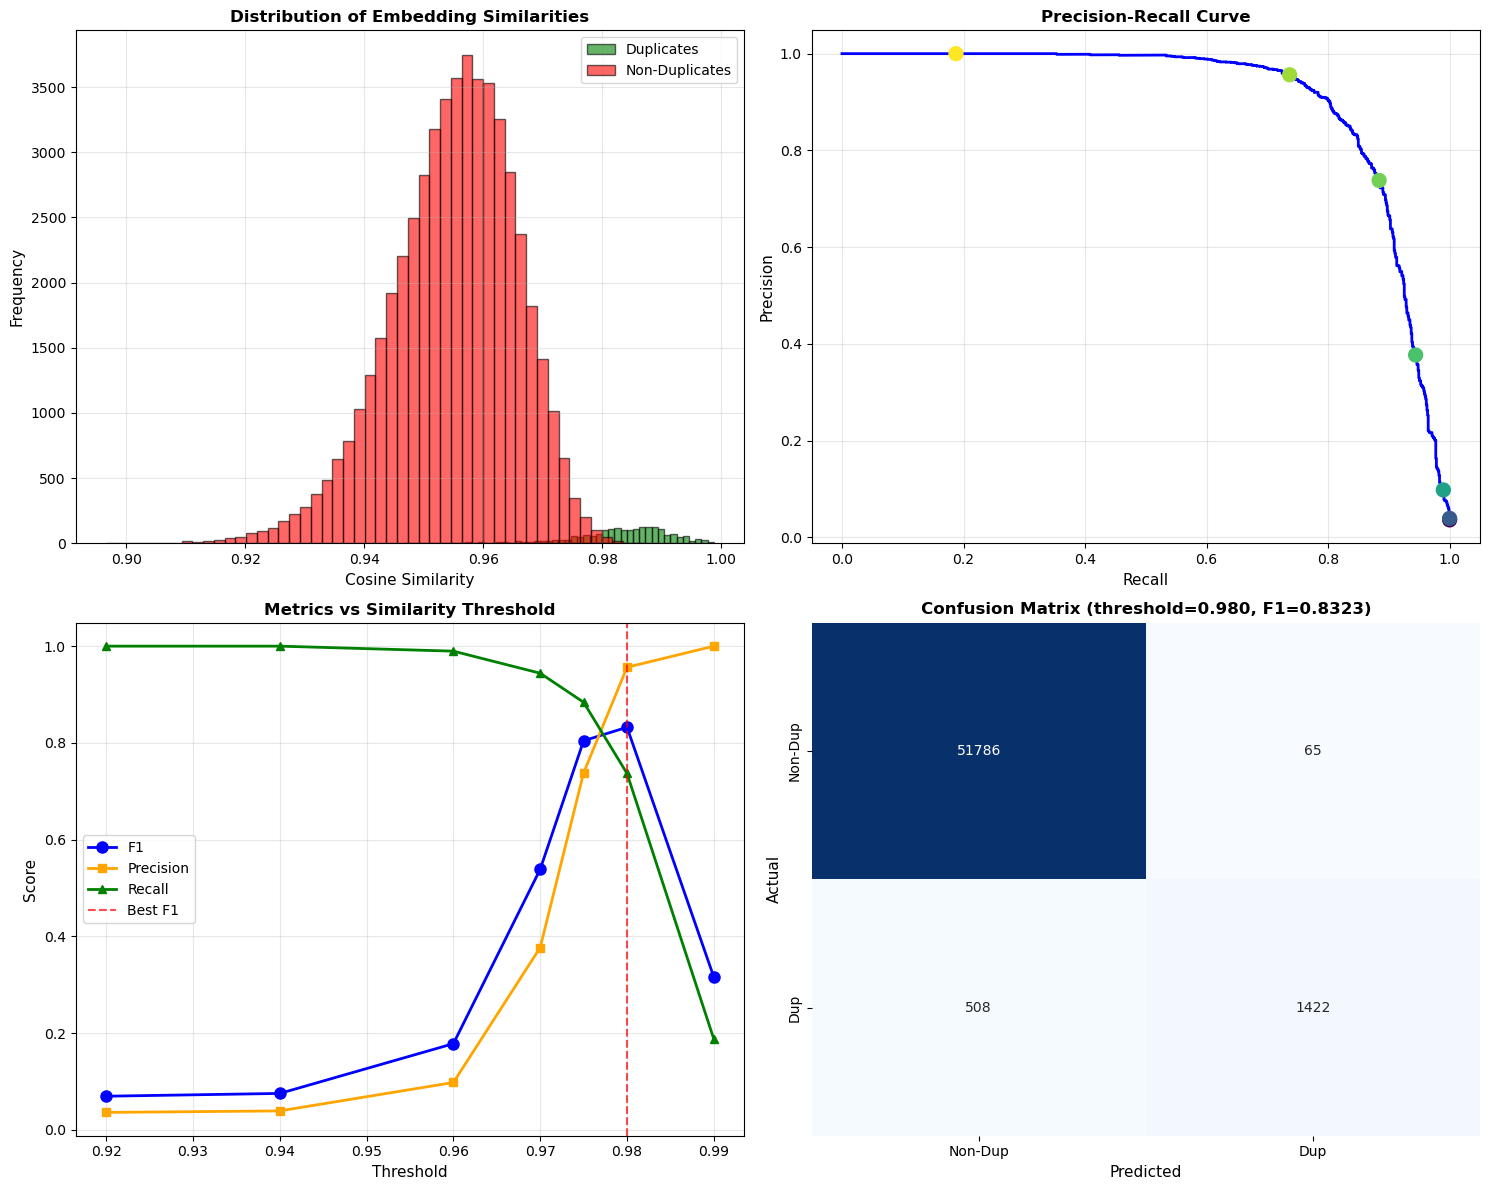


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035991 1.000000 0.069481  0.038787 1930 51695    0   156
     0.940   0.039085 1.000000 0.075229  0.117718 1930 47450    0  4401
     0.960   0.097848 0.989637 0.178089  0.672189 1910 17610   20 34241
     0.970   0.376836 0.944041 0.538655  0.941968 1822  3013  108 48838
     0.975   0.737889 0.883938 0.804338  0.984567 1706   606  224 51245
     0.980   0.956288 0.736788 0.832309  0.989346 1422    65  508 51786
     0.990   1.000000 0.187565 0.315881  0.970845  362     0 1568 51851
  ✓ Best F1: 0.8323 at threshold 0.980

[15/16] Testing embed_dim=64, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.8767 at threshold 0.975


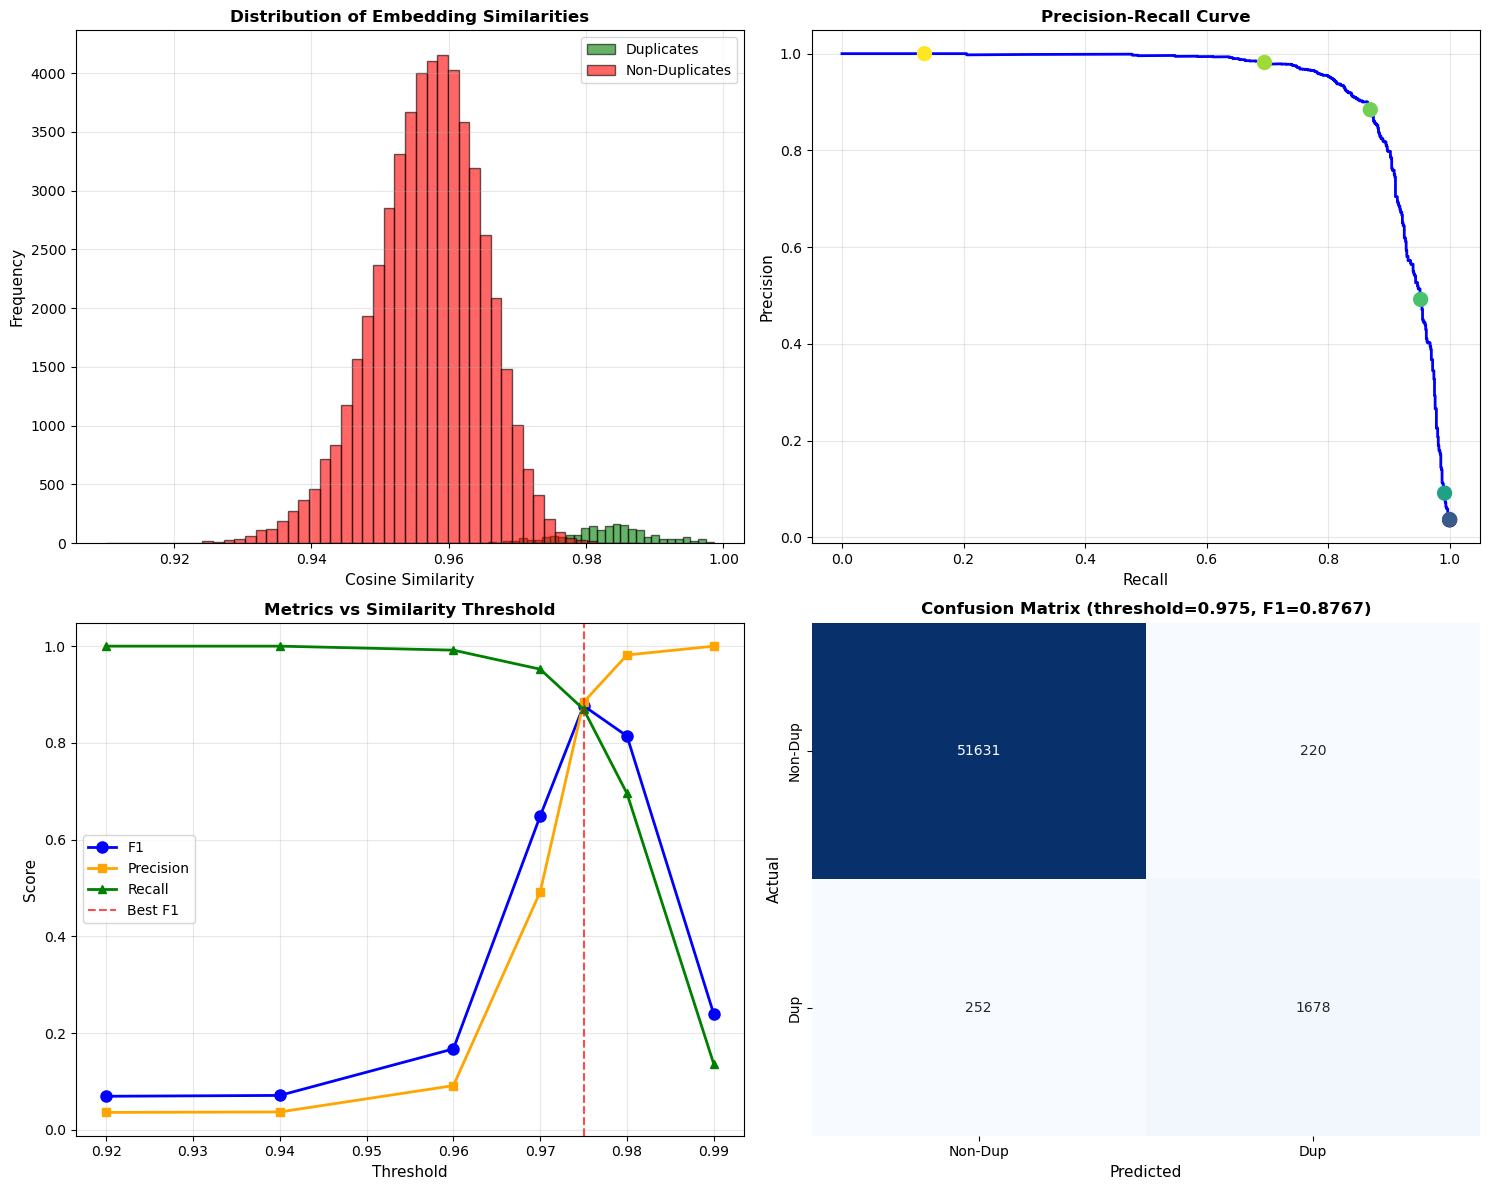


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035896 1.000000 0.069304  0.036147 1930 51837    0    14
     0.940   0.036810 1.000000 0.071007  0.060988 1930 50501    0  1350
     0.960   0.091299 0.991710 0.167205  0.645488 1914 19050   16 32801
     0.970   0.491838 0.952332 0.648668  0.962979 1838  1899   92 49952
     0.975   0.884089 0.869430 0.876698  0.991224 1678   220  252 51631
     0.980   0.981712 0.695337 0.814073  0.988602 1342    25  588 51826
     0.990   1.000000 0.135751 0.239051  0.968985  262     0 1668 51851
  ✓ Best F1: 0.8767 at threshold 0.975

[16/16] Testing embed_dim=64, output_dim=256
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=256

   Best F1: 0.8867 at threshold 0.975


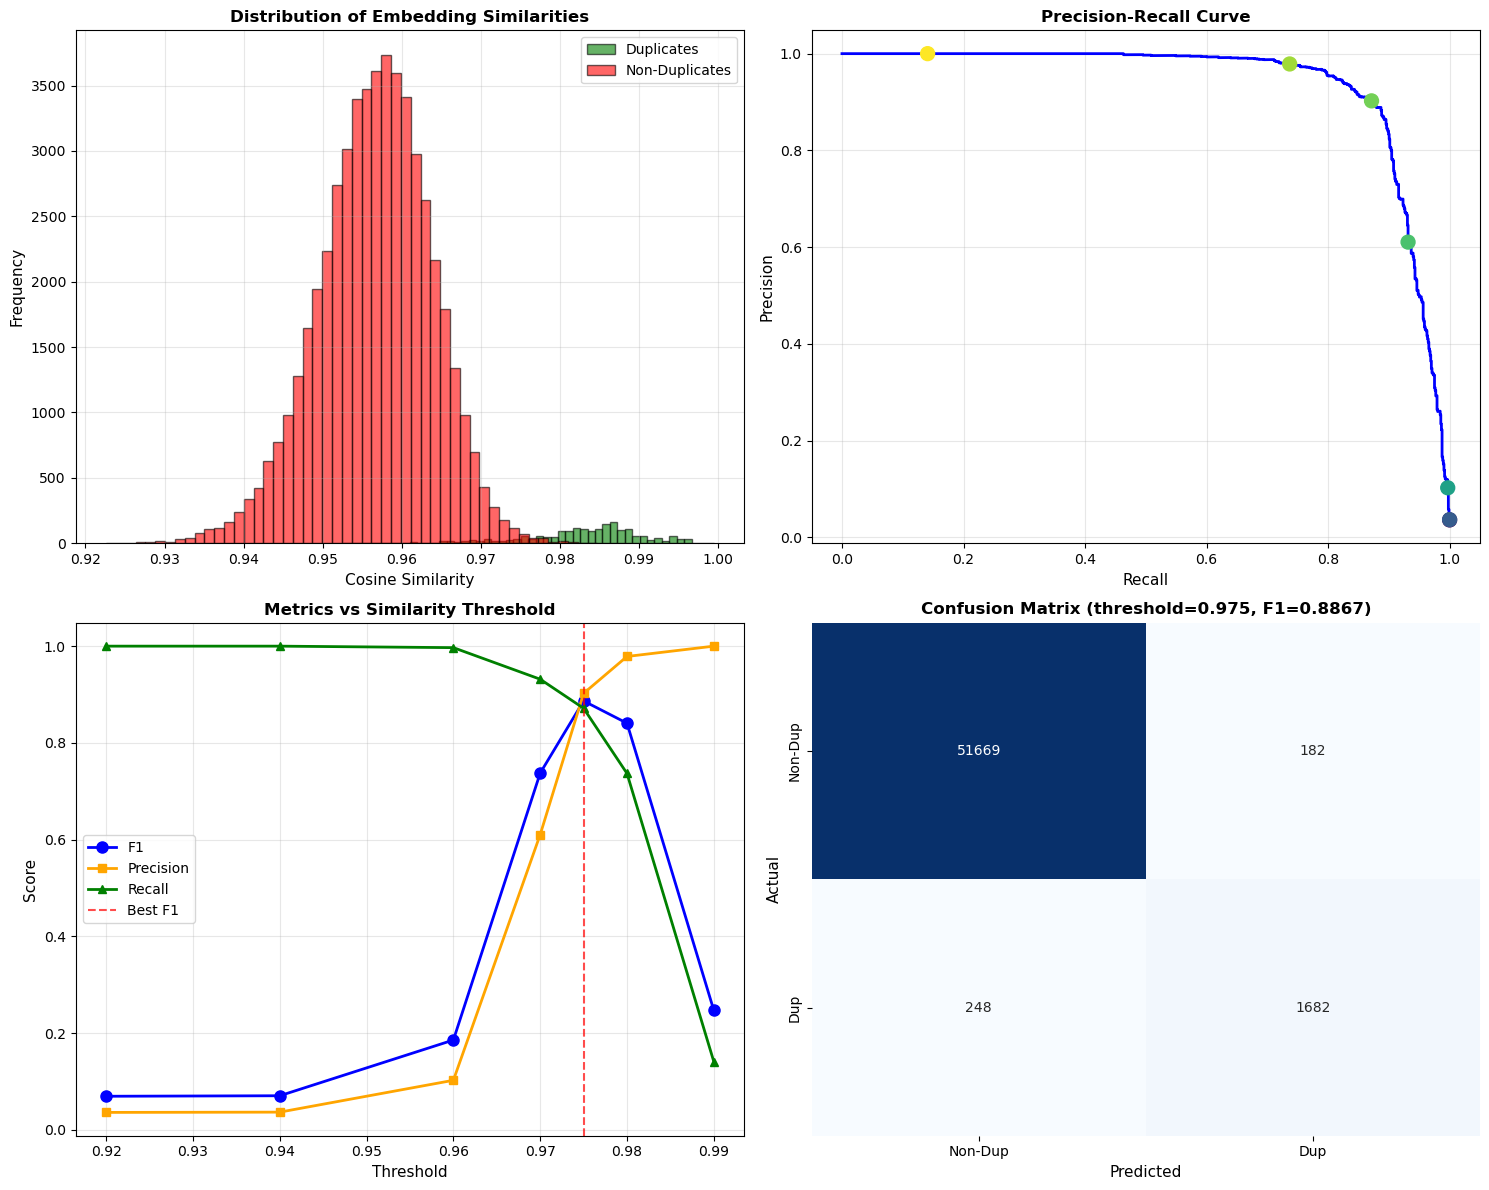


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.036447 1.000000 0.070330  0.051263 1930 51024    0   827
     0.960   0.102297 0.996891 0.185553  0.685949 1924 16884    6 34967
     0.970   0.610319 0.931606 0.737490  0.976200 1798  1148  132 50703
     0.975   0.902361 0.871503 0.886663  0.992005 1682   182  248 51669
     0.980   0.978665 0.736788 0.840674  0.989978 1422    31  508 51820
     0.990   1.000000 0.140933 0.247048  0.969171  272     0 1658 51851
  ✓ Best F1: 0.8867 at threshold 0.975

GRID SEARCH COMPLETED


In [ ]:
# Grid search: Test F1 scores across different embed_dim and output_dim
print("Running grid search across embed_dim and output_dim...")
print("=" * 70)

# Define parameter ranges
embed_dims = [16, 32, 48, 64]
output_dims = [32, 64, 128, 256]

# Create a matrix to store F1 scores
f1_matrix = pd.DataFrame(
    index=[f"embed_{e}" for e in embed_dims],
    columns=[f"output_{o}" for o in output_dims],
    dtype=float
)

# Keep track of results
all_results = {}

# Iterate through all combinations
total_combinations = len(embed_dims) * len(output_dims)
current = 0

for embed_dim in embed_dims:
    for output_dim in output_dims:
        current += 1
        print(f"\n[{current}/{total_combinations}] Testing embed_dim={embed_dim}, output_dim={output_dim}")
        
        try:
            results = evaluate_model(
                ids_data=train_ids_data,
                pairs_data=train_last_name_pairs,
                vocab_size=38,
                embed_dim=embed_dim,
                num_filters=128,
                kernel_sizes=(3, 4, 5),
                dropout=0.3,
                output_dim=output_dim
            )
            
            f1_score = results['best_f1']
            threshold = results['best_threshold']
            
            f1_matrix.loc[f"embed_{embed_dim}", f"output_{output_dim}"] = f1_score
            all_results[(embed_dim, output_dim)] = {
                'f1': f1_score,
                'threshold': threshold,
                'metrics': results['metrics_df']
            }
            
            print(f"  ✓ Best F1: {f1_score:.4f} at threshold {threshold:.3f}")
            
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
            f1_matrix.loc[f"embed_{embed_dim}", f"output_{output_dim}"] = np.nan

print("\n" + "=" * 70)
print("GRID SEARCH COMPLETED")
print("=" * 70)
print(f1_matrix)

In [223]:
print(f1_matrix)

          output_32  output_64  output_128  output_256
embed_16   0.522070   0.719868    0.733333    0.851870
embed_32   0.651859   0.803039    0.879157    0.887010
embed_48   0.554989   0.745523    0.842326    0.887260
embed_64   0.718358   0.832309    0.876698    0.886663
